In [14]:
%pip install matplotlib

You should consider upgrading via the 'c:\Users\andyk\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [15]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\andyk\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [16]:
import sys
import os

base_dir = 'c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-analytics-service\\lambdas\\etl'
# pretend you're in the normal directory
os.chdir(base_dir)
print(os.getcwd())

# in order to access all the other stuff
# hate path manipulation so much why can't coding be easy
sys.path.append(base_dir)
sys.path

c:\Users\andyk\OneDrive\Documents\GitHub\puente-serverless\puente-analytics-service\lambdas\etl


['c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-analytics-service\\lambdas\\etl\\notebooks',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\python39.zip',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\DLLs',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\lib',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39',
 '',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages\\win32',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages\\win32\\lib',
 'C:\\Users\\andyk\\AppData\\Roaming\\Python\\Python39\\site-packages\\Pythonwin',
 'c:\\Users\\andyk\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages',
 'c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-analytics-service\\lambdas\\etl',
 'c:\\Users\\andyk\\OneDrive\\Documents\\GitHub\\puente-serverless\\puente-ana

In [17]:
from sqlalchemy import create_engine
import psycopg2
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from shared_modules.env_utils import PG_HOST, PG_DATABASE, PG_PORT, PG_USERNAME, PG_PASSWORD
from shared_modules.utils import connection

In [18]:
conn = connection()
cursor = conn.cursor()
engine = create_engine(f'postgresql://{PG_USERNAME}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}')

In [27]:
env_health_qry = """
select sf.*, fd.*, qd.*, cd.name AS community_name, sod.name AS surveying_organization
from survey_fact sf 
join form_dim fd 
on fd."uuid"  = sf.form_id 
join question_dim qd 
on qd."uuid"  = sf.question_id 
join surveying_organization_dim sod
on sod."uuid" = sf.surveying_organization_id
join community_dim cd
on cd."uuid" = sf.community_id
where fd.name = 'HistoryEnvironmentalHealth'
AND sod.name IN ('puente', 'Puente')
"""
env_health = pd.read_sql(env_health_qry, engine)
env_health

,uuid,surveying_organization_id,surveying_user_id,community_id,question_id,question_answer,created_at,updated_at,form_id,patient_id,...,uuid,question,field_type,formik_key,options,created_at,updated_at,form_id,community_name,surveying_organization
0,abf5db8c-7577-4049-b2c5-0bd023595e80,1965ba21-1b96-383f-9581-33ad74c0755e,b7112d6c-5050-3f2e-be91-14ae32ca95d7,26d4082b-cb5a-3f21-9664-00d8f5b62be9,f497fffe-0608-30b3-9043-1d1912bcc550,{Hospital},2022-10-13 21:55:32.664,2023-03-23 23:04:58.036,732f50b7-6220-38b1-81b8-1f2c00ead024,39d25532-43dc-393f-859f-d7431b04f58a,...,f497fffe-0608-30b3-9043-1d1912bcc550,environmentalHealth.clinicAccess.label,selectMulti,clinicAccess_v2,"[Clinic_Medical_Center, Polyclinic, Hospital, ...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,El Tornado,Puente
1,7c75e868-cd87-4920-80e2-4cb9b9f1ddaf,1965ba21-1b96-383f-9581-33ad74c0755e,532e8306-a188-3637-8d17-e352dc7b179a,06bcfd9d-997f-3f90-8e2b-69dc7ecbdbe2,43d55317-c1d6-31cc-b8d6-5e5e445acf15,"{Street,""other__La luz ""}",2022-10-20 13:51:18.112,2023-03-23 23:05:31.300,732f50b7-6220-38b1-81b8-1f2c00ead024,f5e09596-07f2-3fb9-886e-21815fae3189,...,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Laculata,Puente
2,59d7fc39-9eac-4f91-9f37-8bca520e4288,1965ba21-1b96-383f-9581-33ad74c0755e,b7112d6c-5050-3f2e-be91-14ae32ca95d7,26d4082b-cb5a-3f21-9664-00d8f5b62be9,43d55317-c1d6-31cc-b8d6-5e5e445acf15,"{""other__La bulla ""}",2022-10-13 21:55:32.664,2023-03-23 23:04:58.036,732f50b7-6220-38b1-81b8-1f2c00ead024,39d25532-43dc-393f-859f-d7431b04f58a,...,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,El Tornado,Puente
3,bb592e8b-3e2a-43d0-b42d-0c1c5af56dfc,1965ba21-1b96-383f-9581-33ad74c0755e,532e8306-a188-3637-8d17-e352dc7b179a,06bcfd9d-997f-3f90-8e2b-69dc7ecbdbe2,43d55317-c1d6-31cc-b8d6-5e5e445acf15,"{Street,Sanitation,AccessToBathrooms}",2022-08-04 15:43:28.107,2023-03-23 23:02:28.049,732f50b7-6220-38b1-81b8-1f2c00ead024,2abb0366-1912-3740-85c2-290f39c42c9d,...,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Laculata,Puente
4,c0c867c1-bc1b-4e24-89dd-283c429ccedf,1965ba21-1b96-383f-9581-33ad74c0755e,532e8306-a188-3637-8d17-e352dc7b179a,06bcfd9d-997f-3f90-8e2b-69dc7ecbdbe2,43d55317-c1d6-31cc-b8d6-5e5e445acf15,"{Street,Sanitation,AccessToBathrooms}",2022-08-04 15:43:28.259,2023-03-23 23:02:28.049,732f50b7-6220-38b1-81b8-1f2c00ead024,dbc0156c-2b81-3106-af42-3bdbd4d5122f,...,43d55317-c1d6-31cc-b8d6-5e5e445acf15,environmentalHealth.biggestProblemComm.label,selectMulti,biggestproblemofcommunity_v2,"[Water, Trash, Street, AccessToBathrooms, Hous...",2024-04-15 19:06:12.727352,2024-04-15 19:06:12.727352,732f50b7-6220-38b1-81b8-1f2c00ead024,Laculata,Puente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153544,33fd75a1-95de-4ff5-bec5-b72a12c3285c,1965ba21-1b96-383f-9581-33ad74c0755e,532e8306-a188-3637-8d17-e352dc7b179a,06bcfd9d-997f-3f90-8e2b-69dc7ecbdbe2,83726f5d-9423-303e-986a-5df03d81281f,"{under_5__2,6_12__2,13_18__1}",2021-12-10 03:52:11.477,2023-03-23 22:58:23.111,732f50b7-6220-38b1-81b8-1f2c00ead024,27e43210-7ea9-392e-9cc5-7197d4801ab9,...,83726f5d-9423-303e-986a-5df03d81281f,environmentalHealth.numberChildrenUnder5.label,selectMulti,numberofChildrenLivinginHouseUndertheAgeof5_v2,"[under_5, 6_12, 13_18]",2024-04-15 19:06:12.727352,2024-04-15 19

In [32]:
questions = env_health["question"].unique()
questions

array(['environmentalHealth.clinicAccess.label',
       'environmentalHealth.biggestProblemComm.label',
       'environmentalHealth.typeOfWater.label',
       'environmentalHealth.bathroomAccess.label',
       'environmentalHealth.latrineAccess',
       'environmentalHealth.dentalAccess',
       'environmentalHealth.timesPerWeekTrash.label',
       'environmentalHealth.houseOwnership.label',
       'environmentalHealth.floorCondition.label',
       'environmentalHealth.floorMaterial.label',
       'environmentalHealth.roofCondition.label',
       'environmentalHealth.typeStove.label',
       'environmentalHealth.houseMaterials.label',
       'environmentalHealth.electricityAccess.label',
       'environmentalHealth.foodSecurity',
       'environmentalHealth.govAssistance.label',
       'environmentalHealth.numberChildrenUnder5.label'], dtype=object)

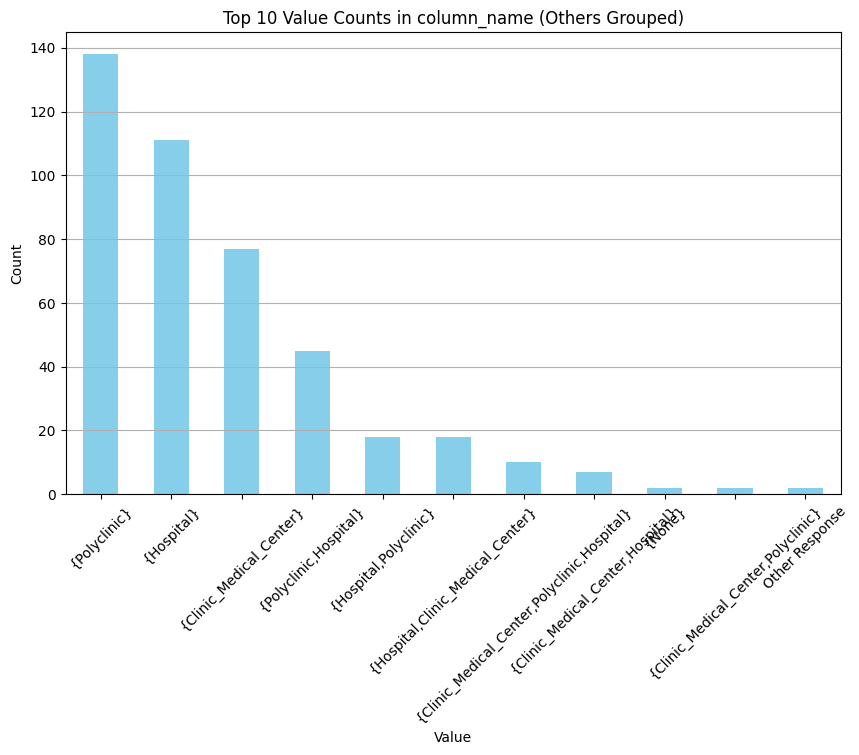

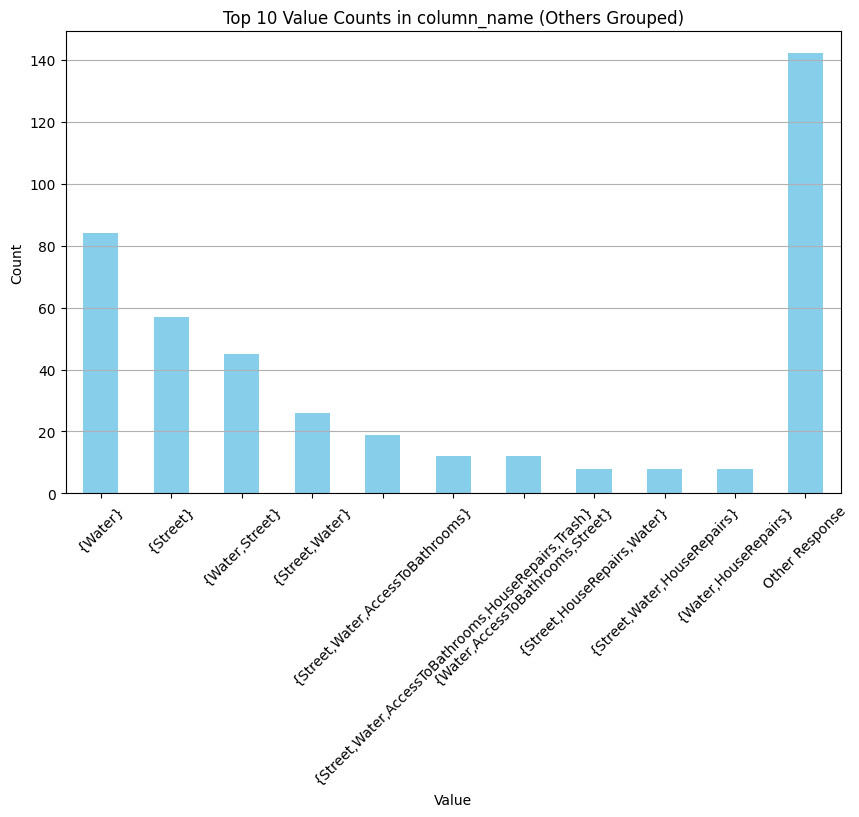

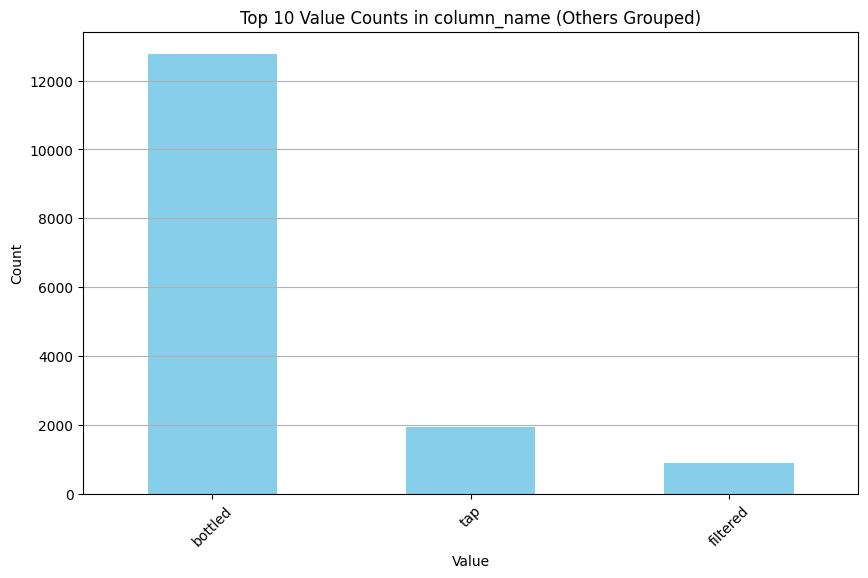

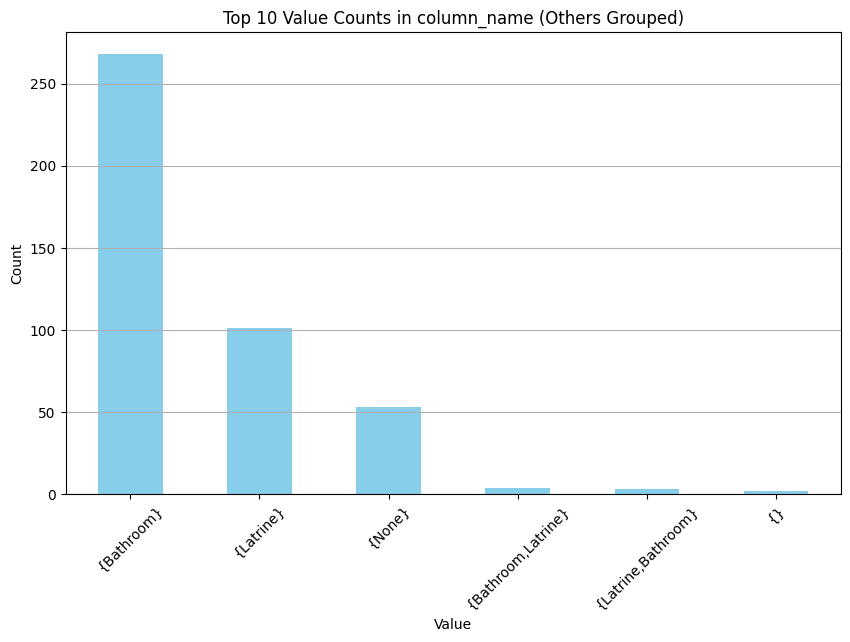

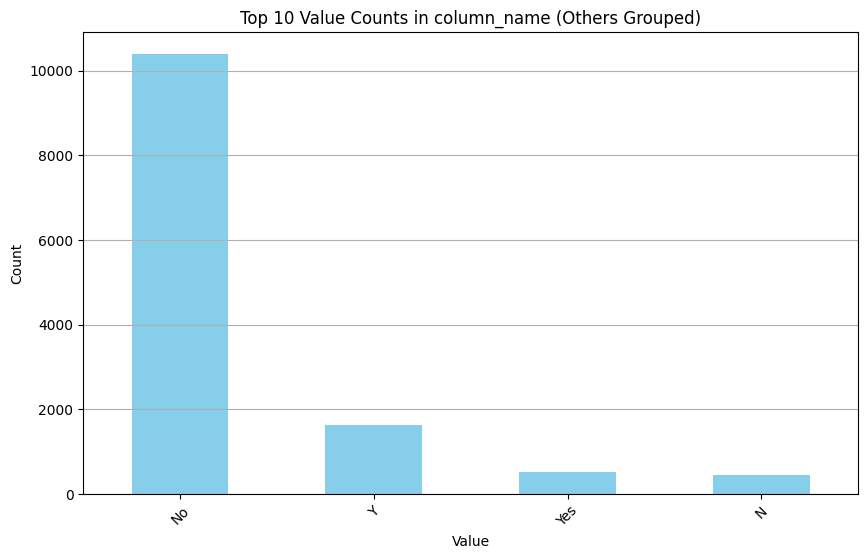

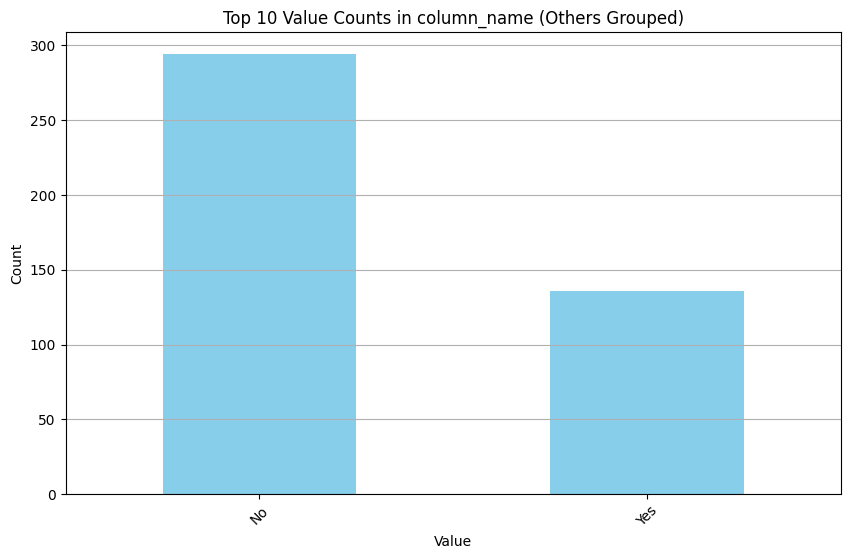

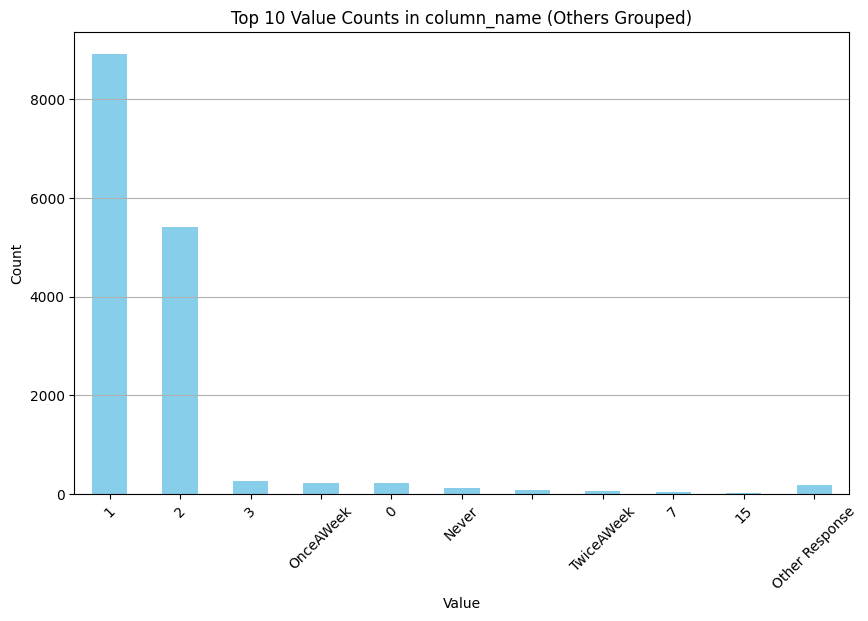

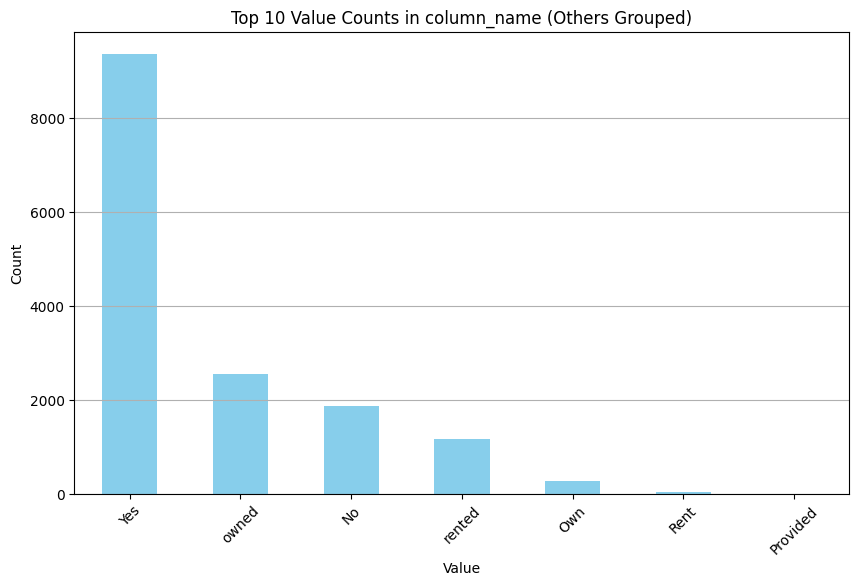

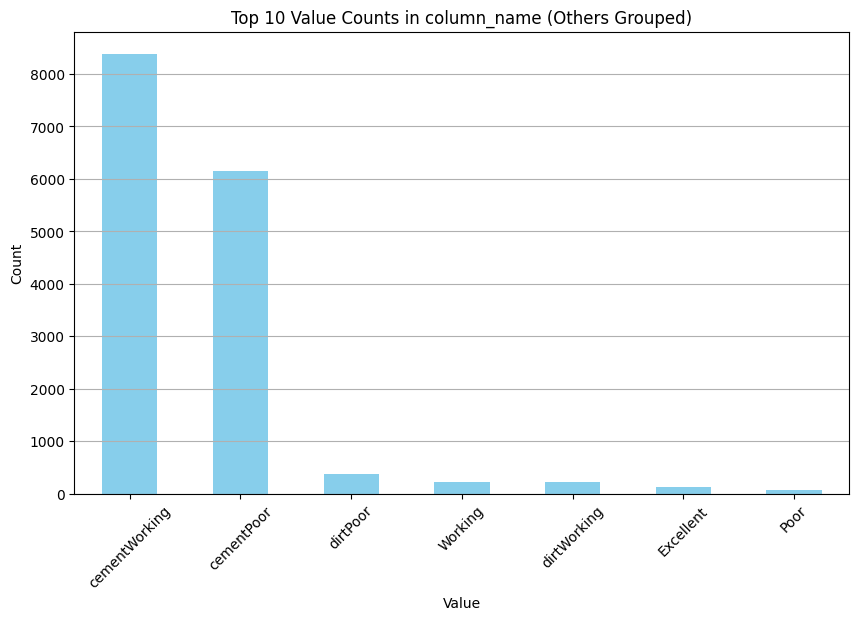

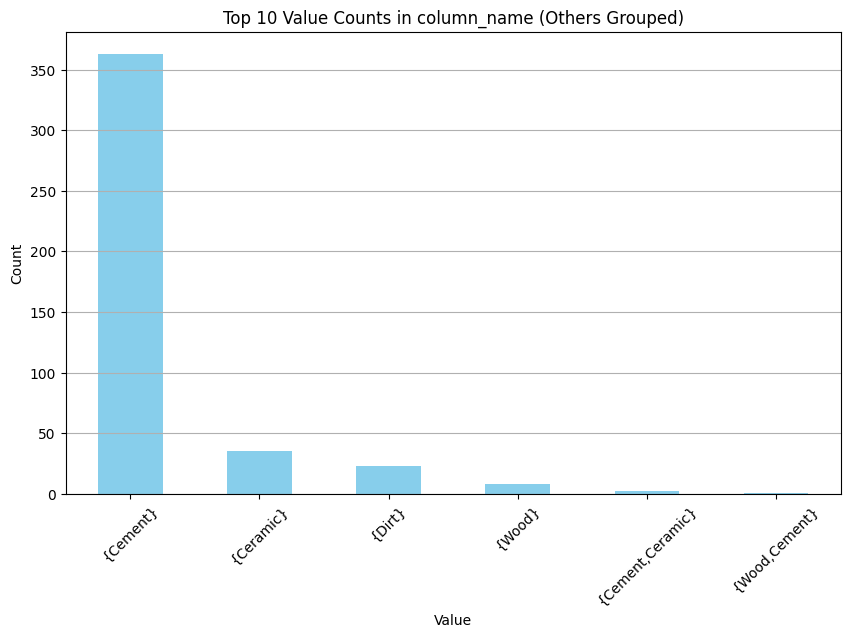

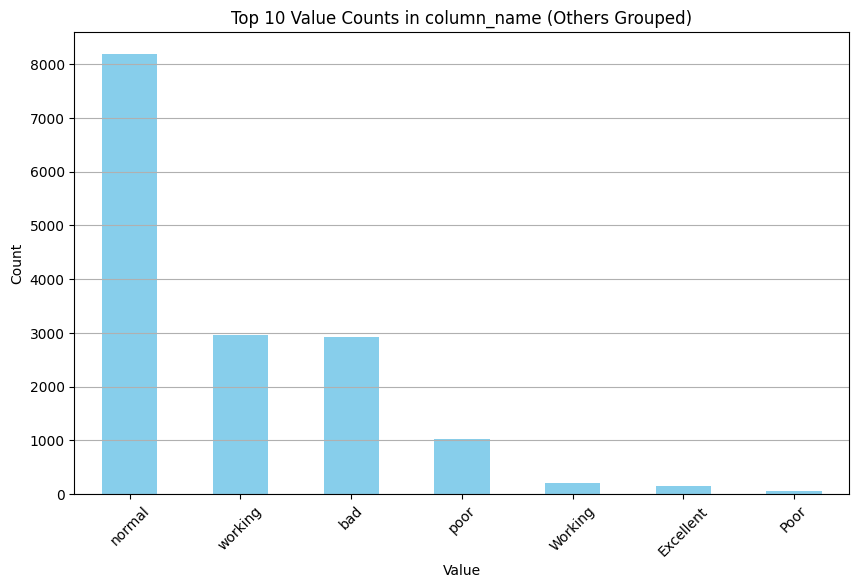

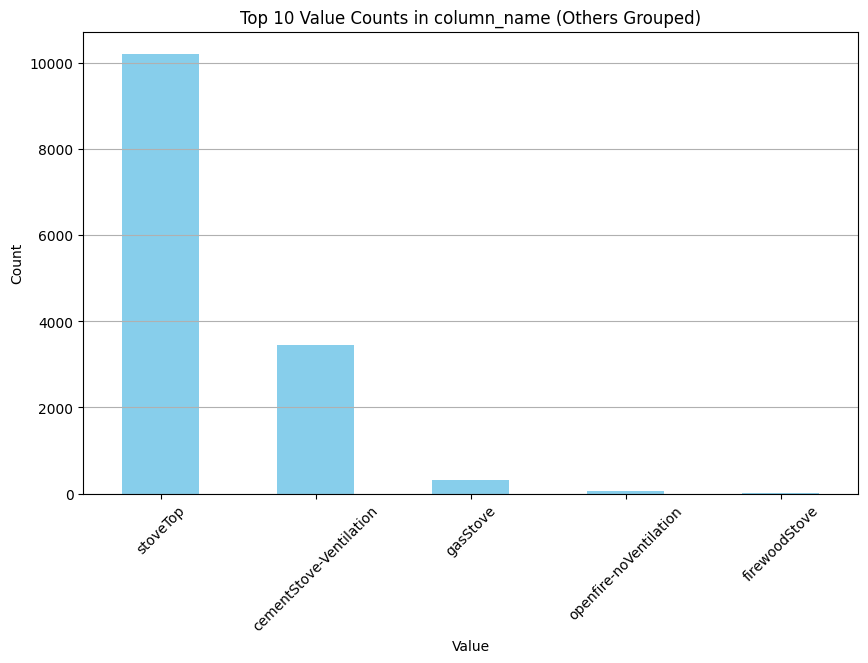

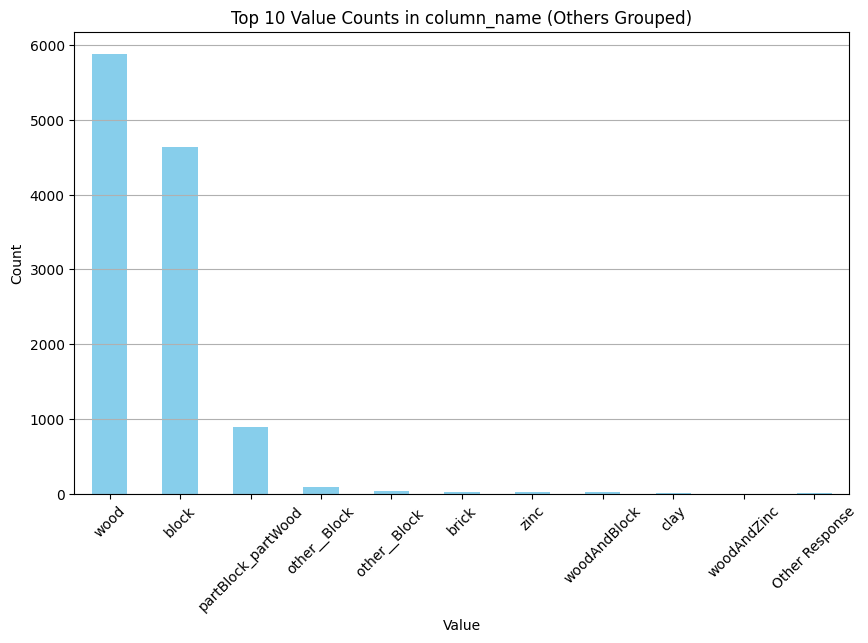

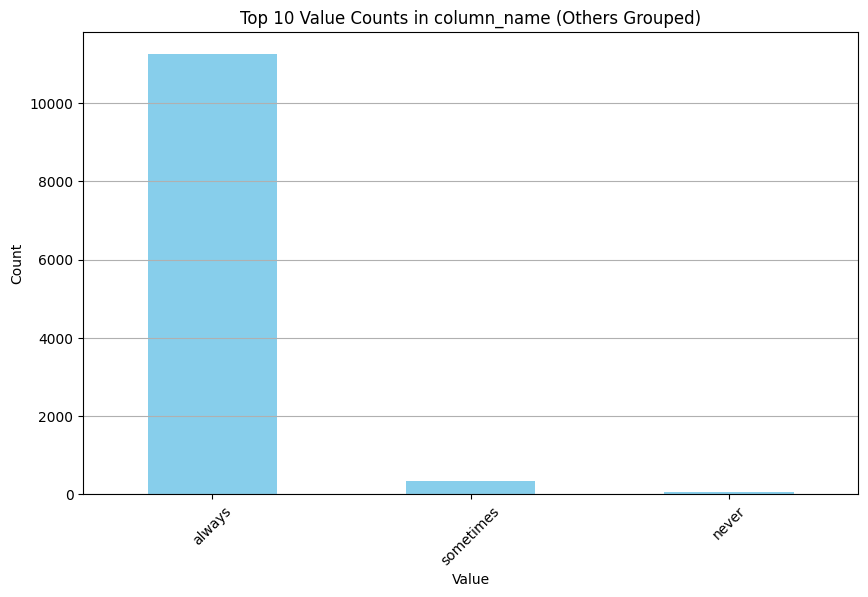

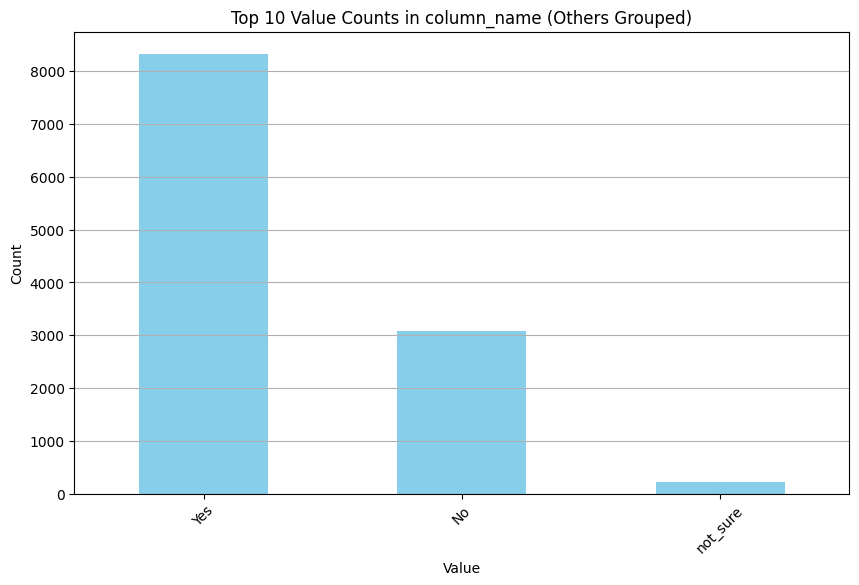

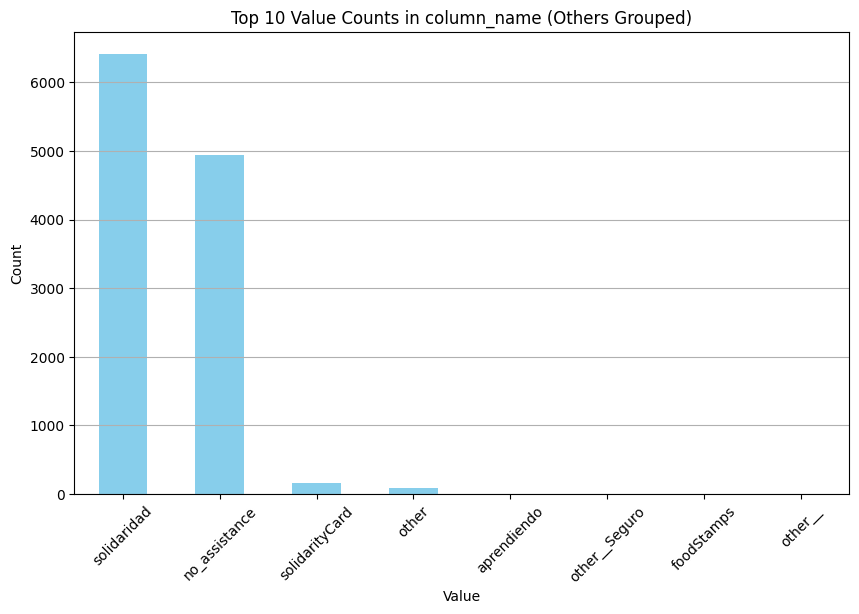

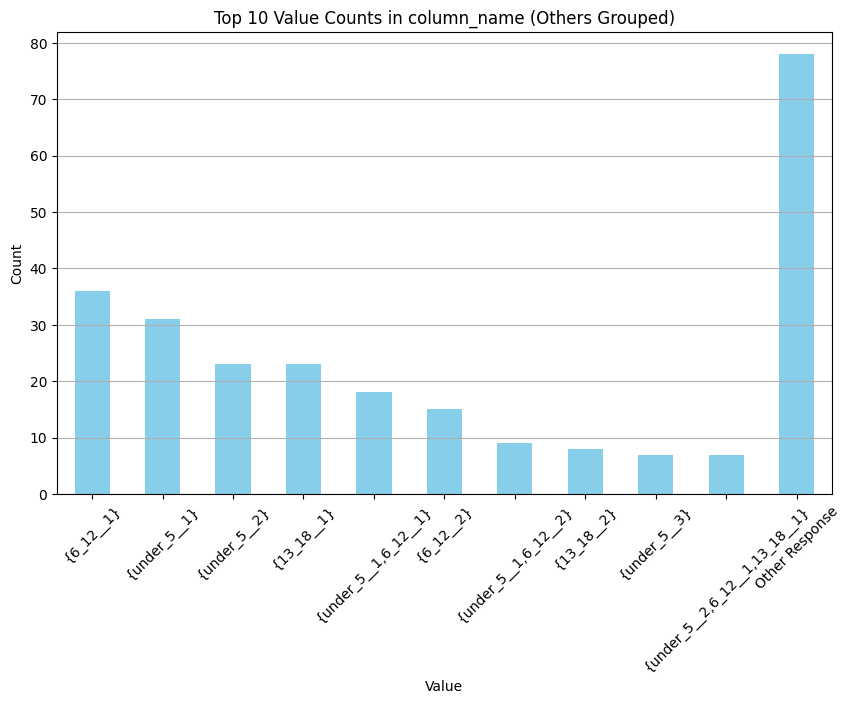

In [29]:

for question in questions:
    answer_counts = env_health.loc[env_health["question"] == question, "question_answer"].value_counts()

    if answer_counts.shape[0] > 10:
        # Get the top 10 values
        plot_df = answer_counts.nlargest(10)

        # Group all other values as "Other Response"
        other_count = answer_counts.iloc[10:].sum()
        plot_df['Other Response'] = other_count
    else:
        plot_df = answer_counts

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    plot_df.plot(kind='bar', color='skyblue')
    plt.title('Top 10 Value Counts in column_name (Others Grouped)')
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y')

    # Show the plot
    plt.show()

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


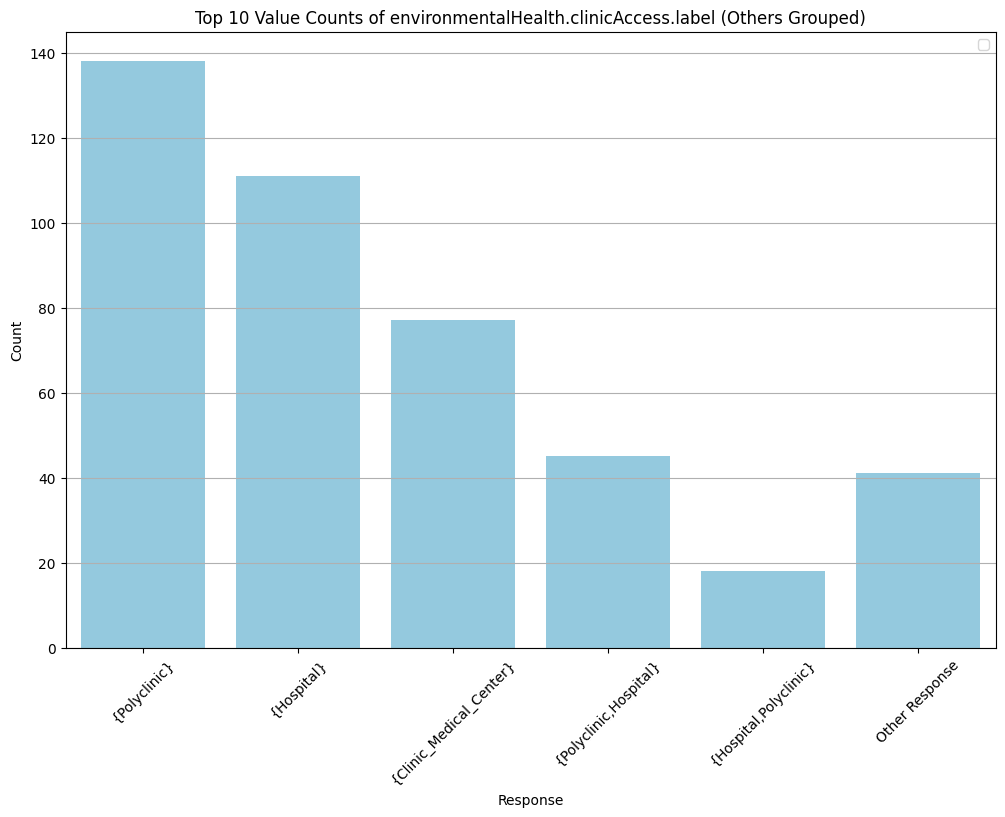

<Figure size 1200x800 with 0 Axes>

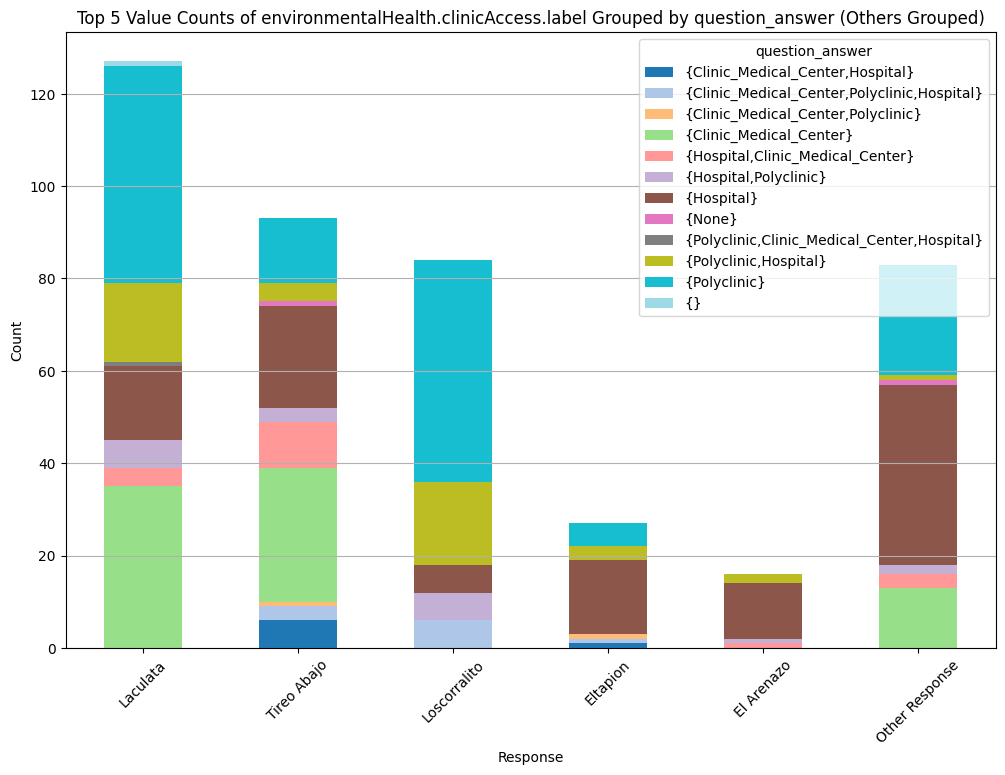

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


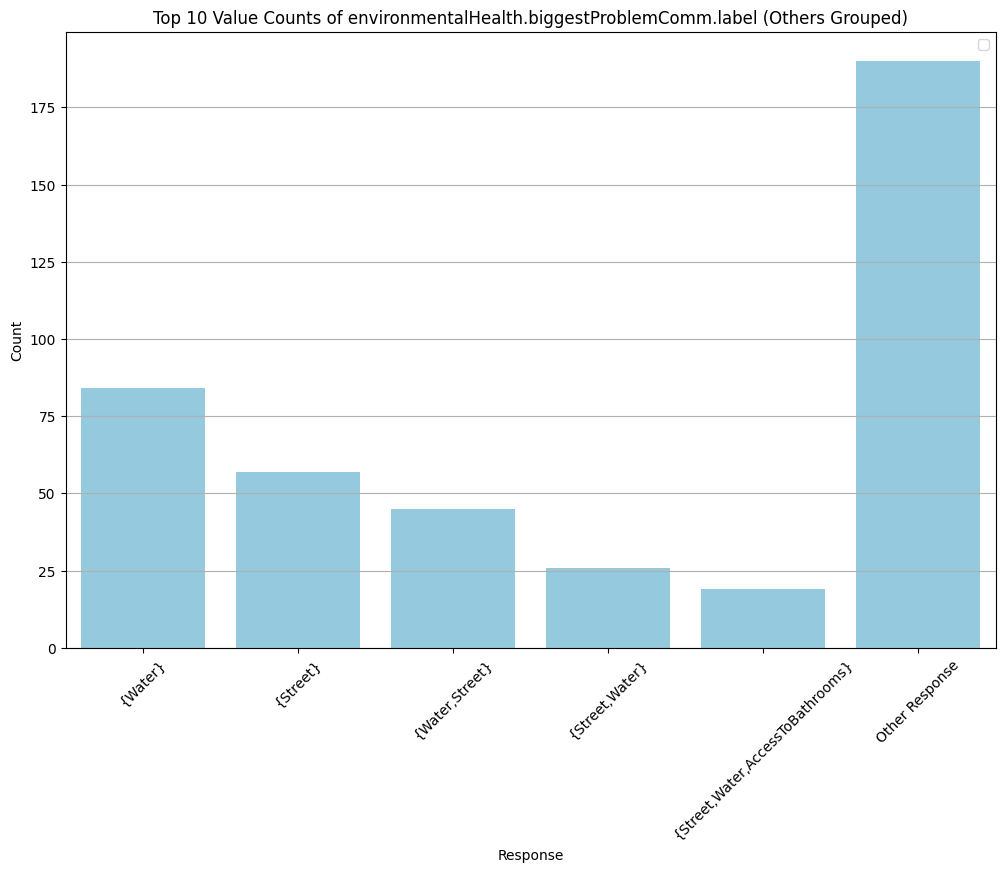

<Figure size 1200x800 with 0 Axes>

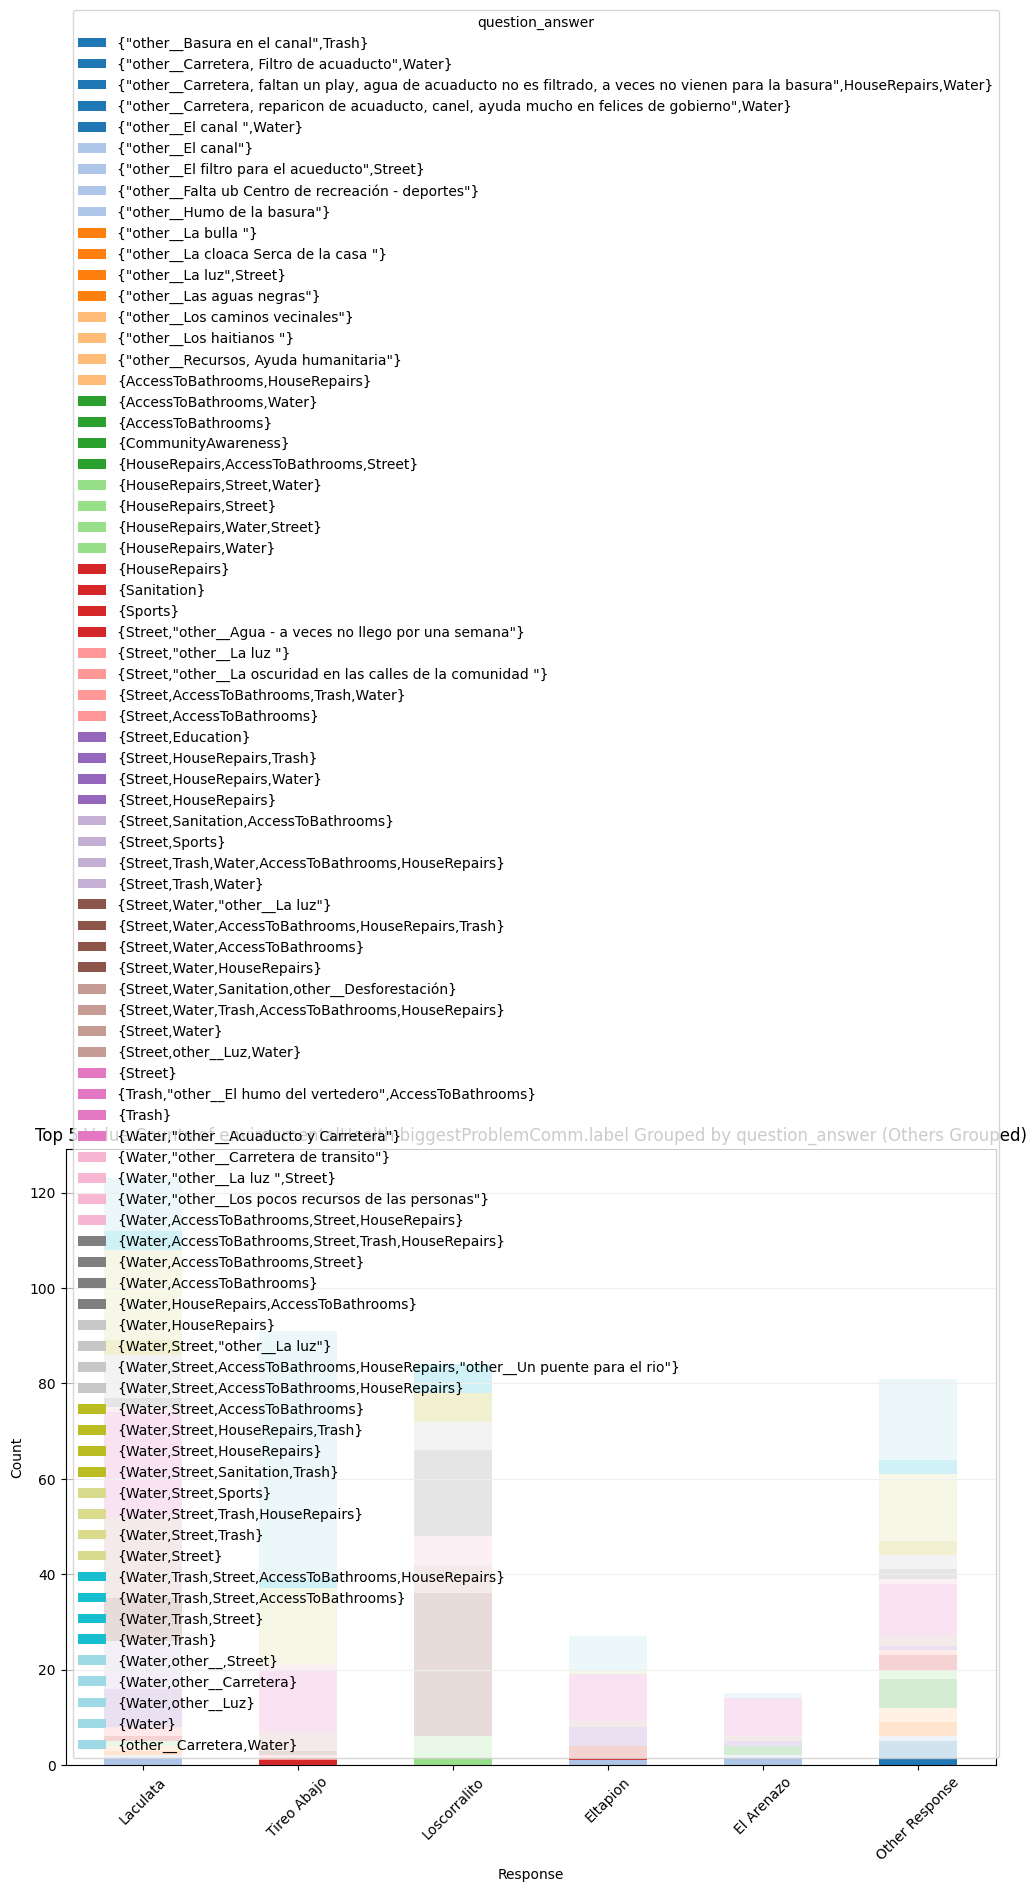

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


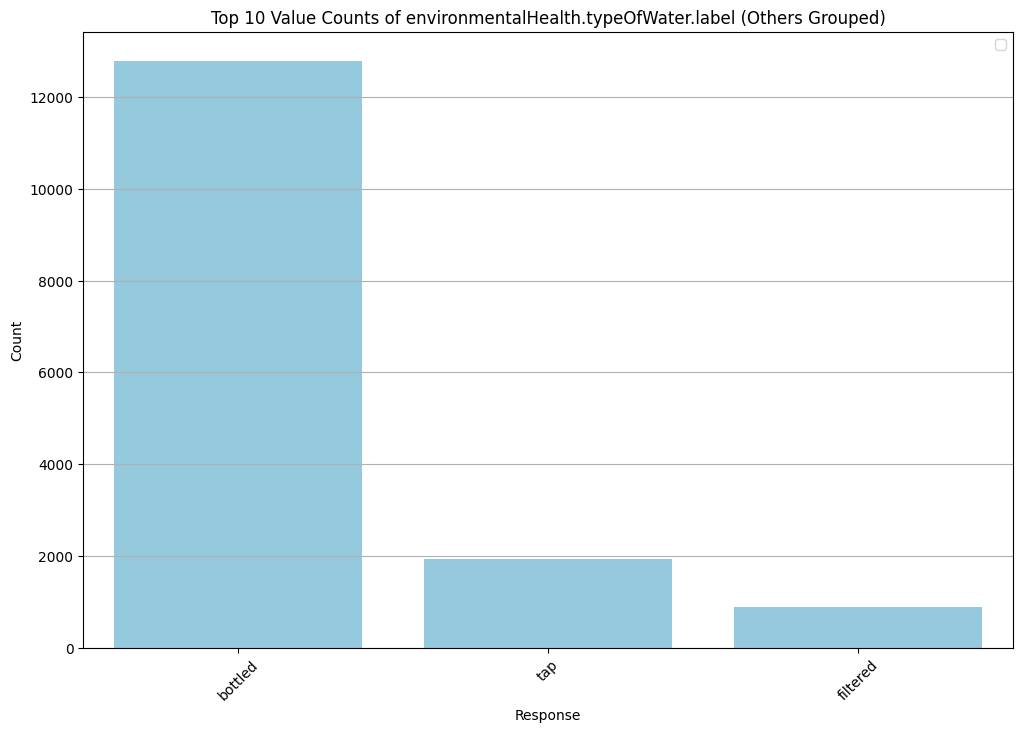

<Figure size 1200x800 with 0 Axes>

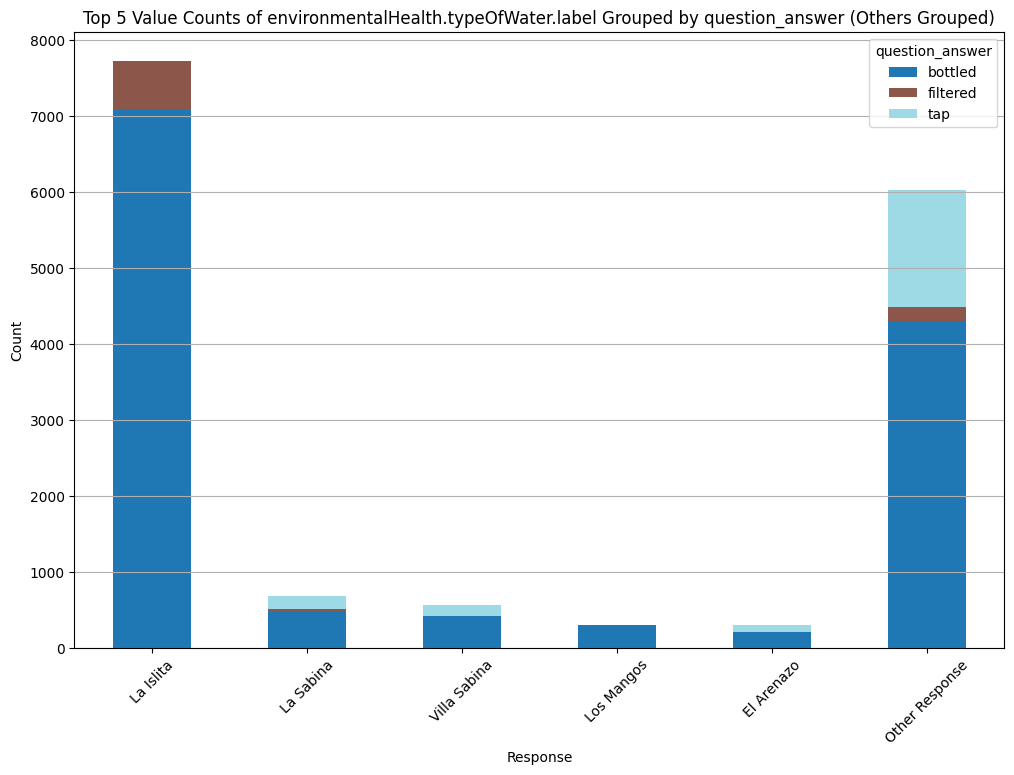

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


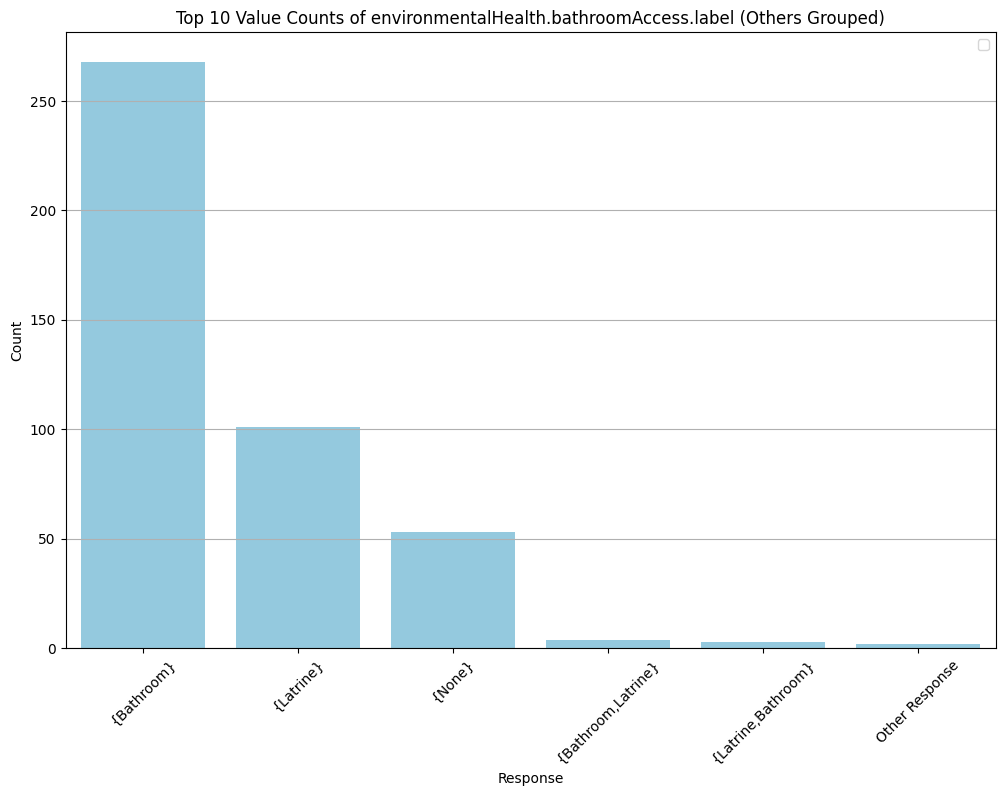

<Figure size 1200x800 with 0 Axes>

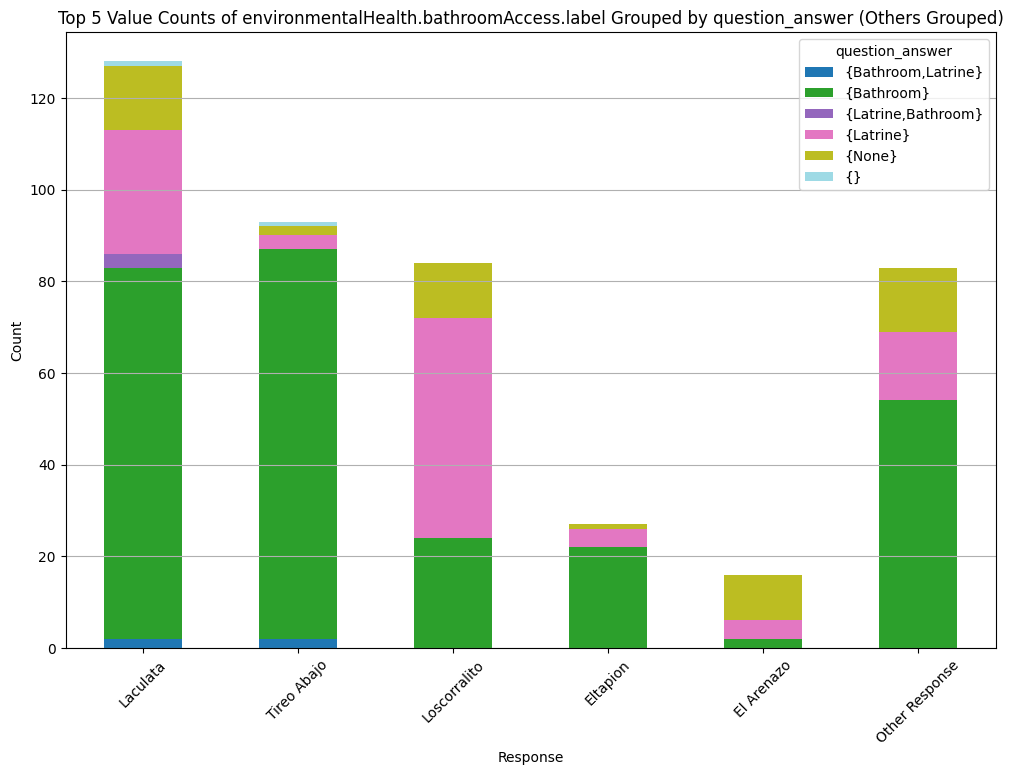

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


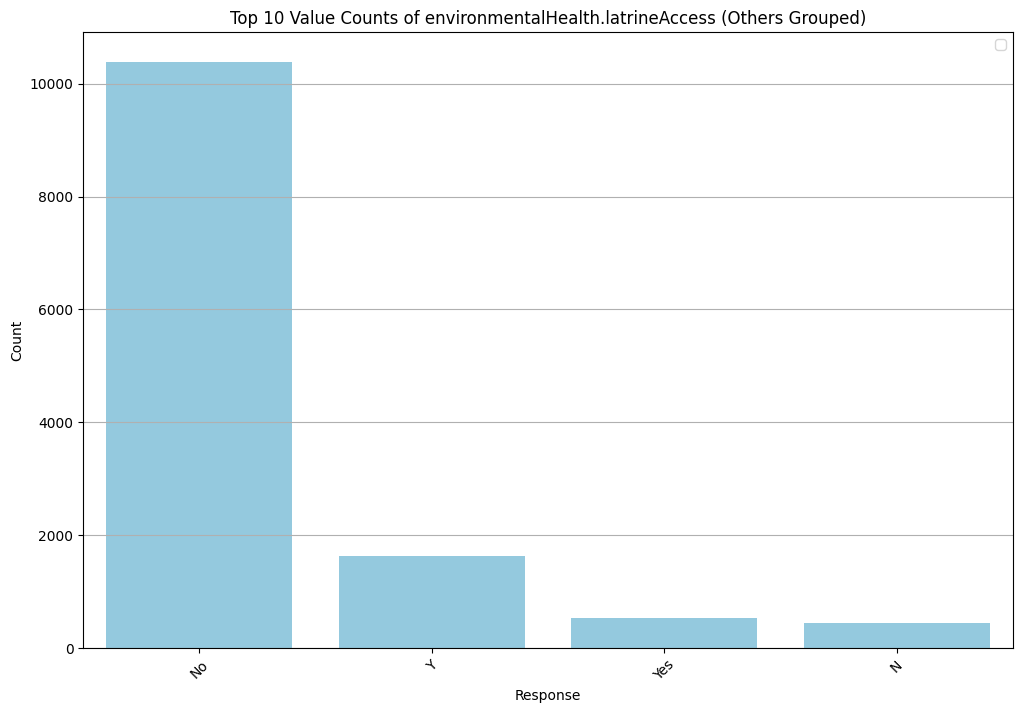

<Figure size 1200x800 with 0 Axes>

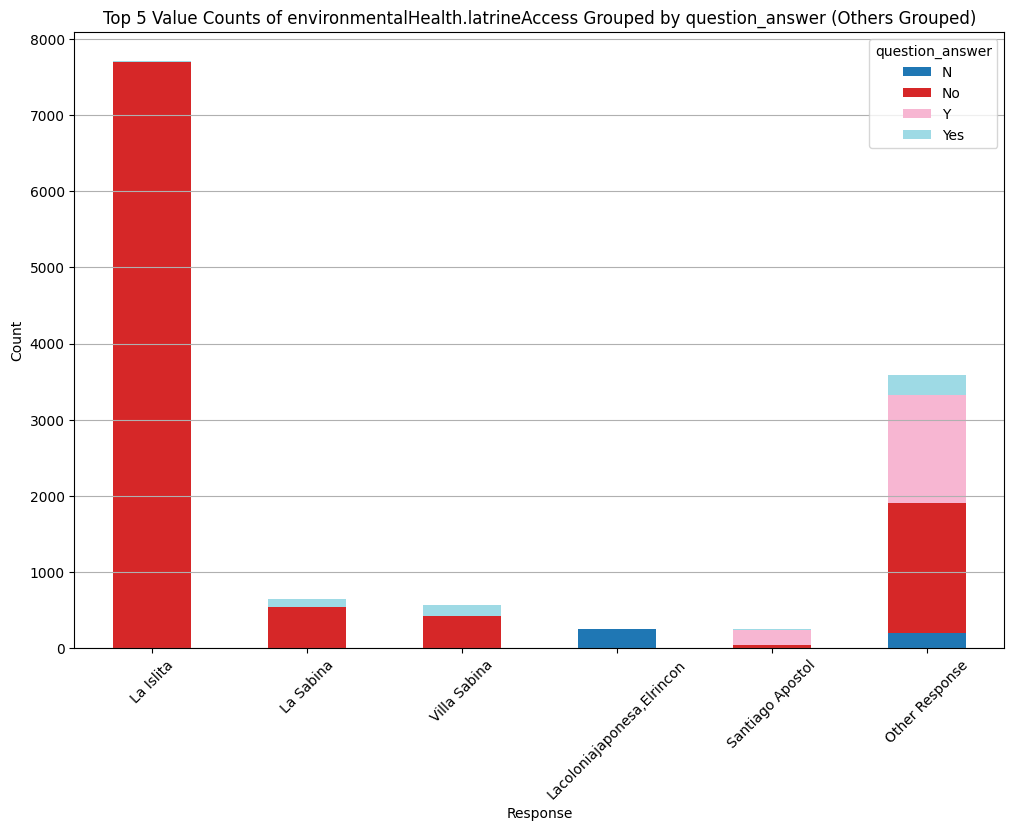

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


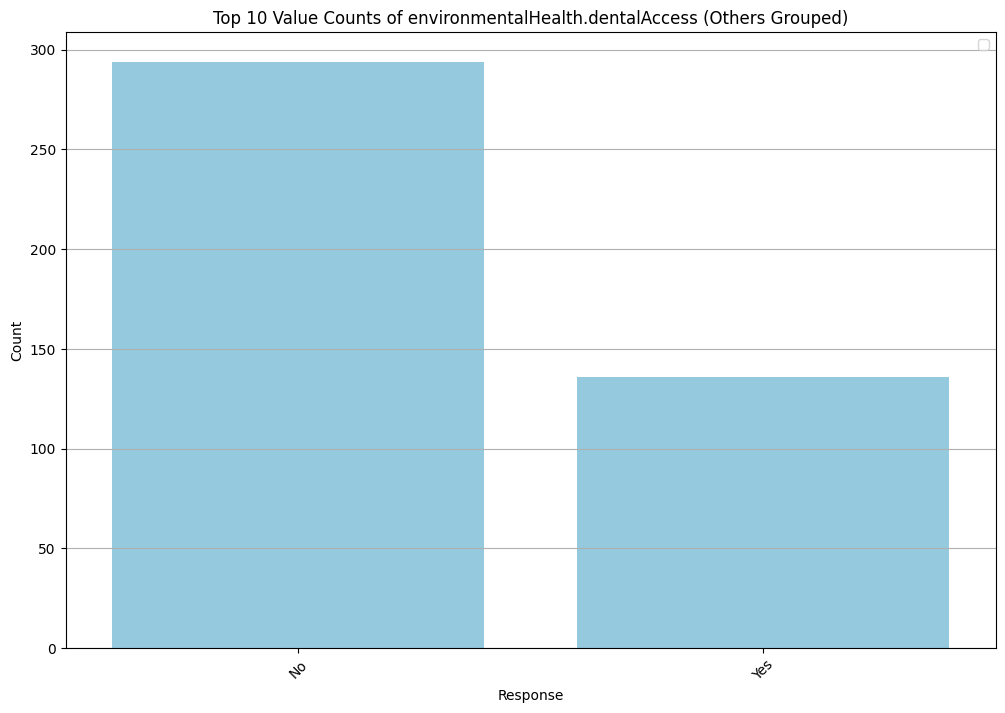

<Figure size 1200x800 with 0 Axes>

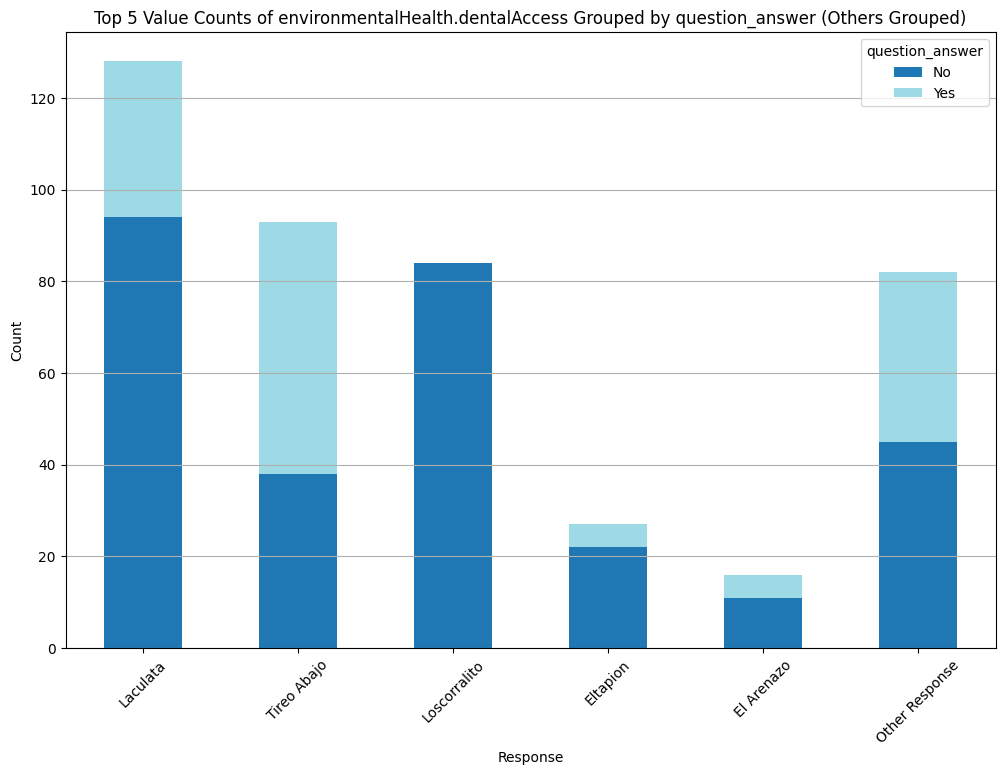

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


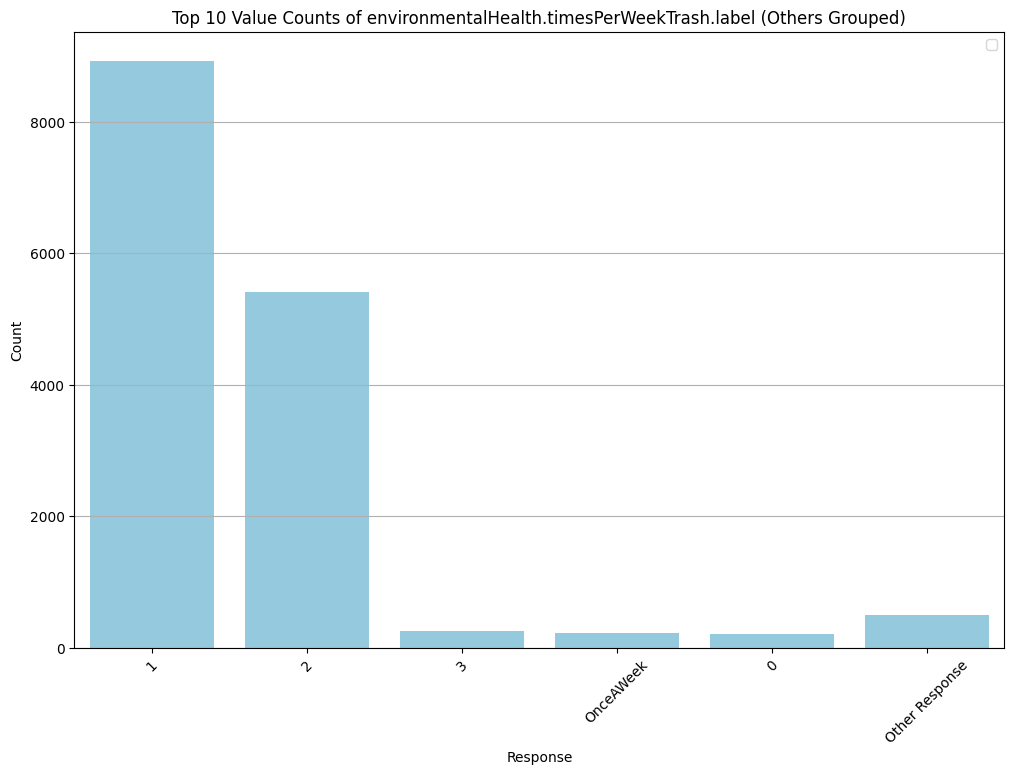

<Figure size 1200x800 with 0 Axes>

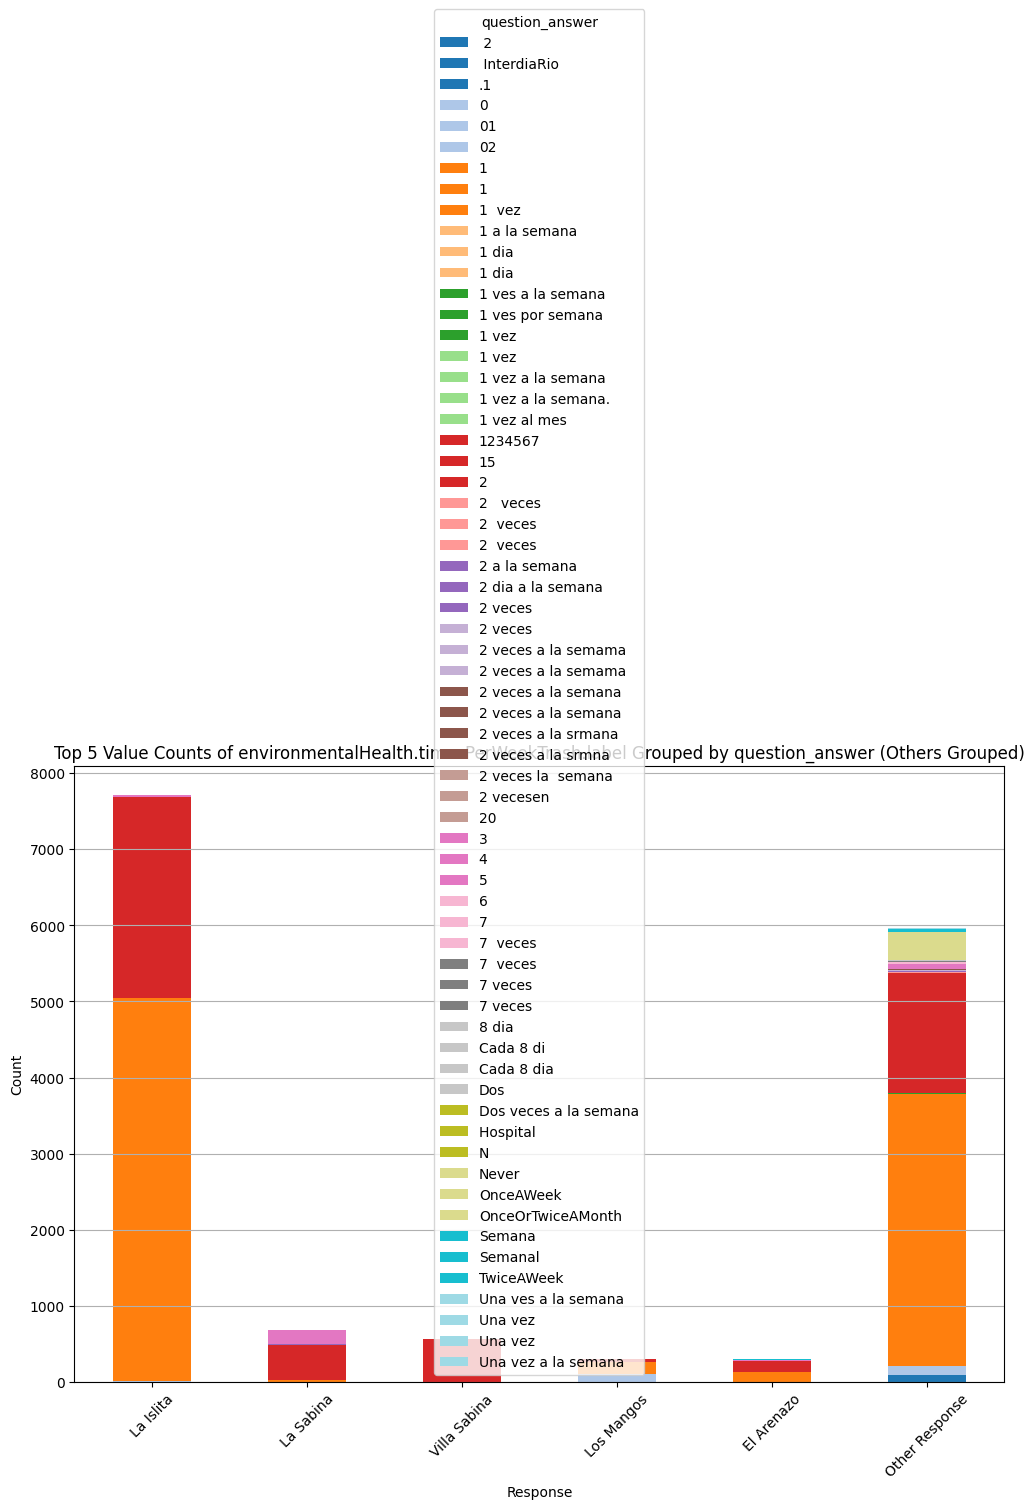

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


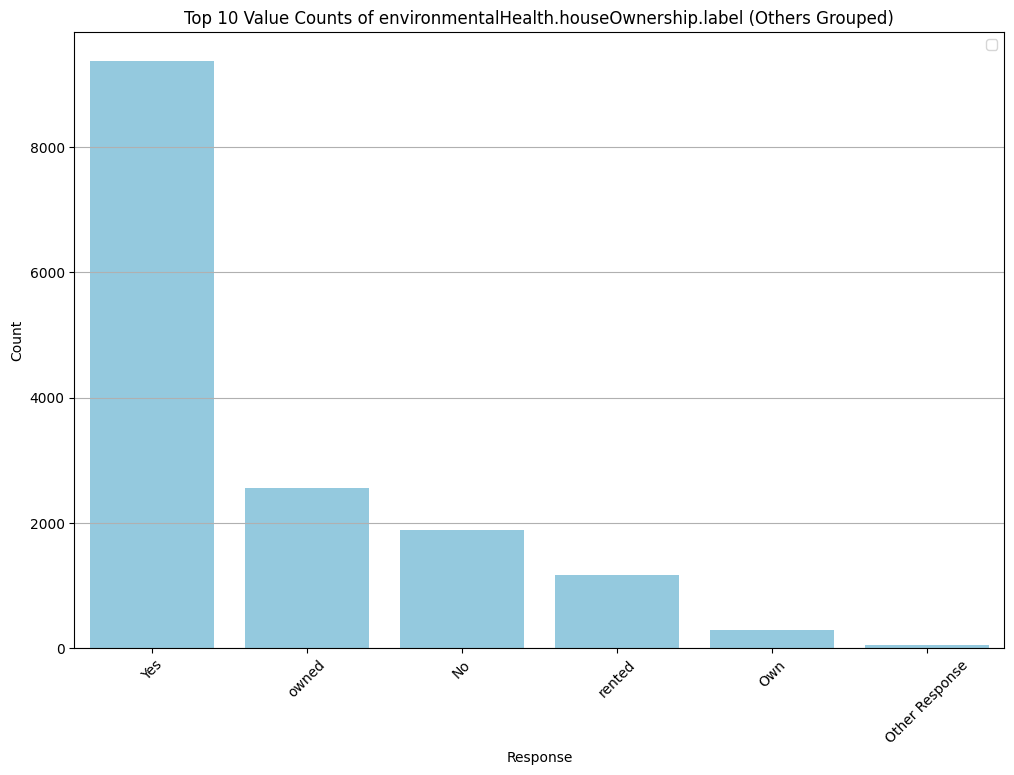

<Figure size 1200x800 with 0 Axes>

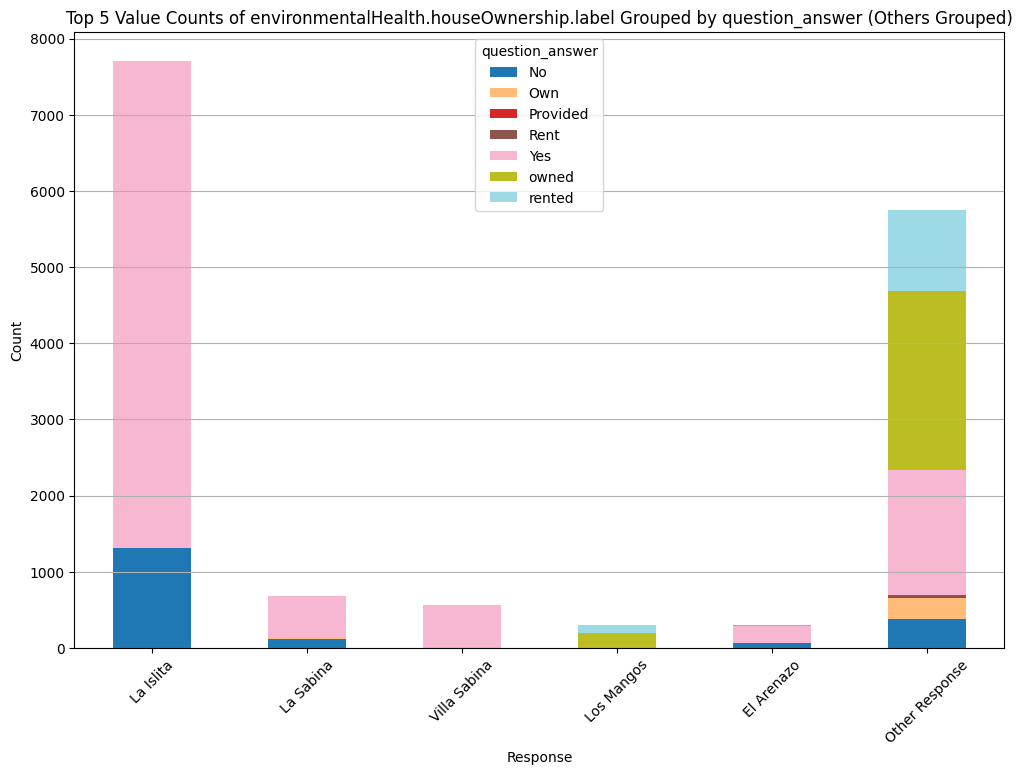

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


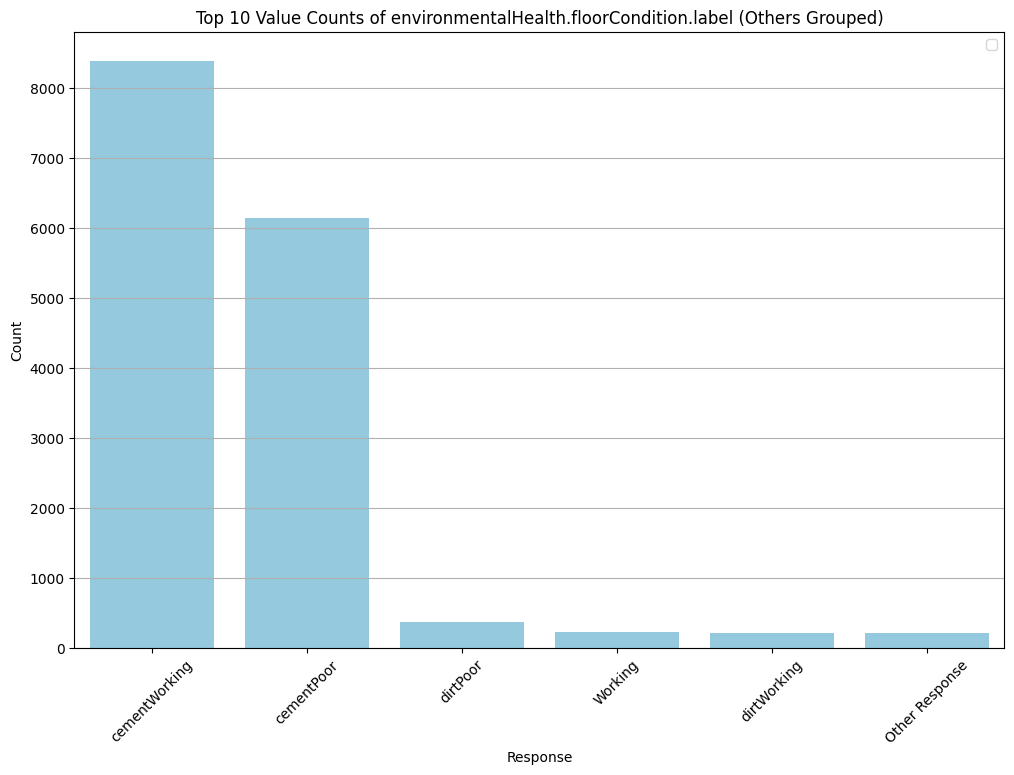

<Figure size 1200x800 with 0 Axes>

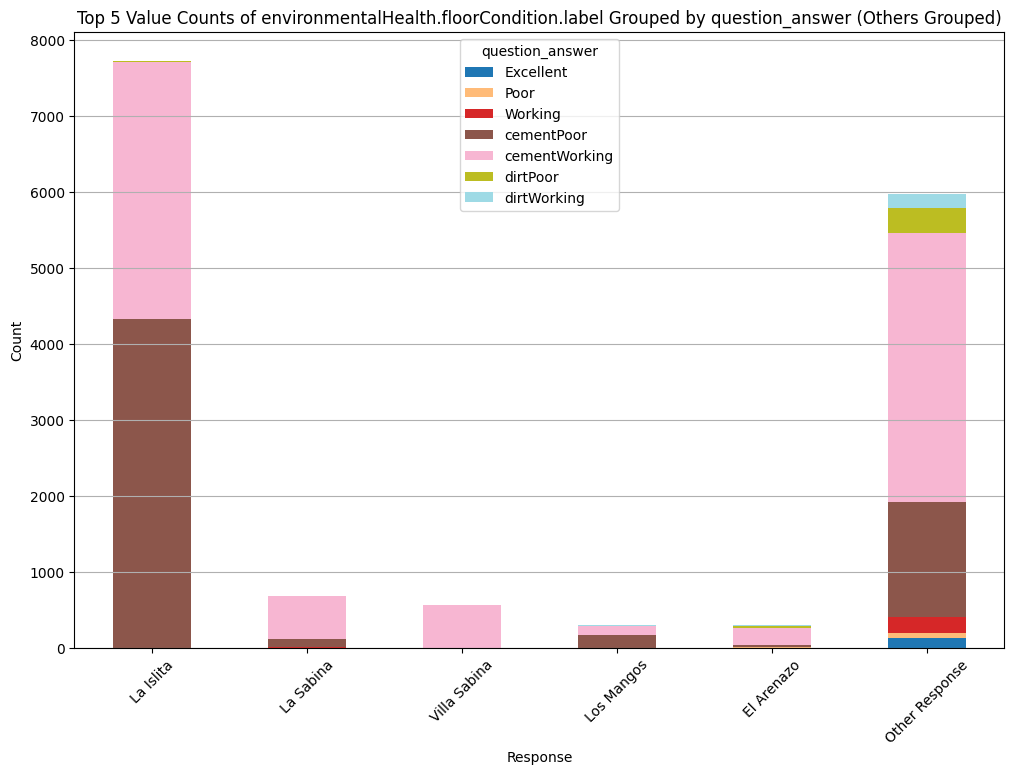

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


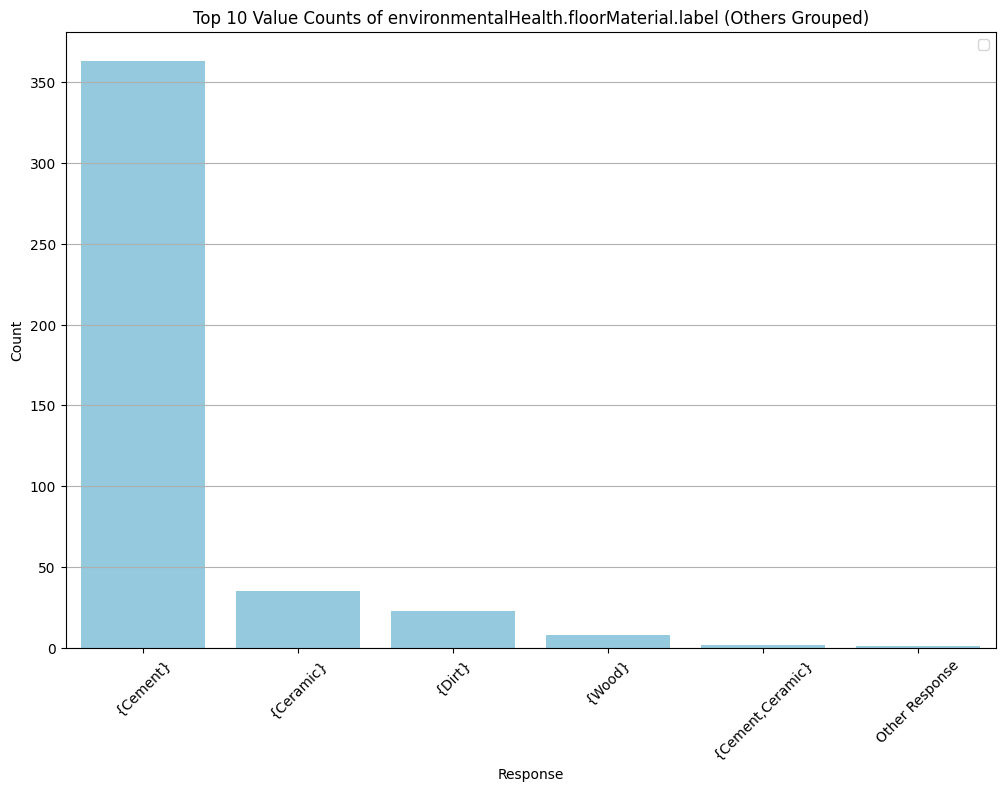

<Figure size 1200x800 with 0 Axes>

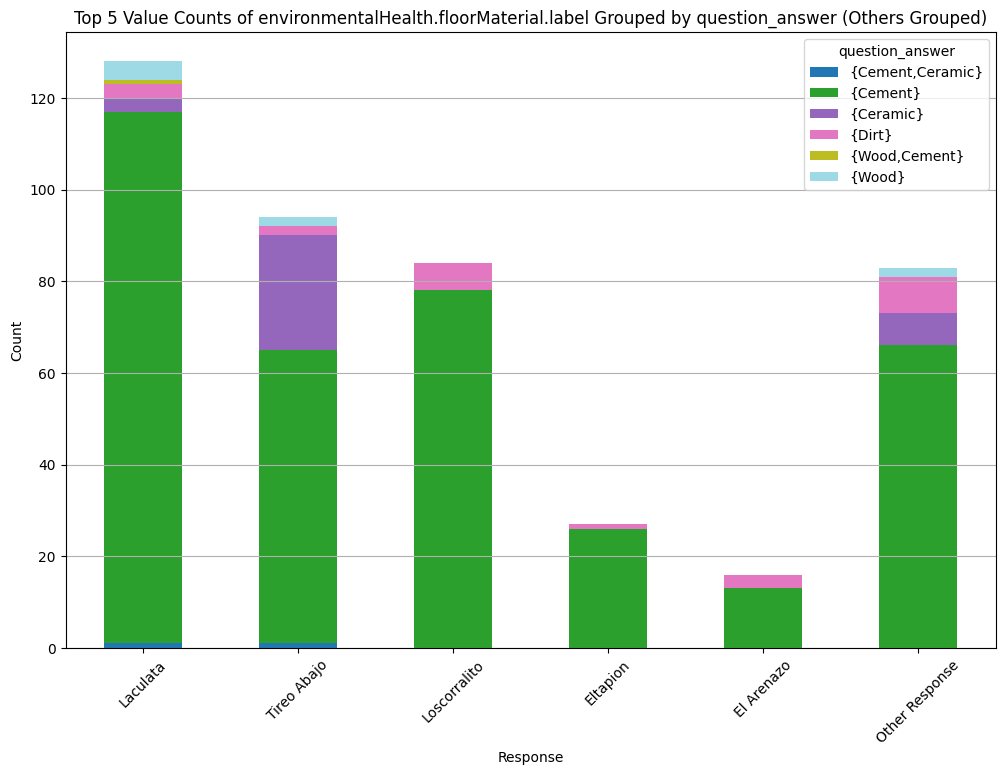

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


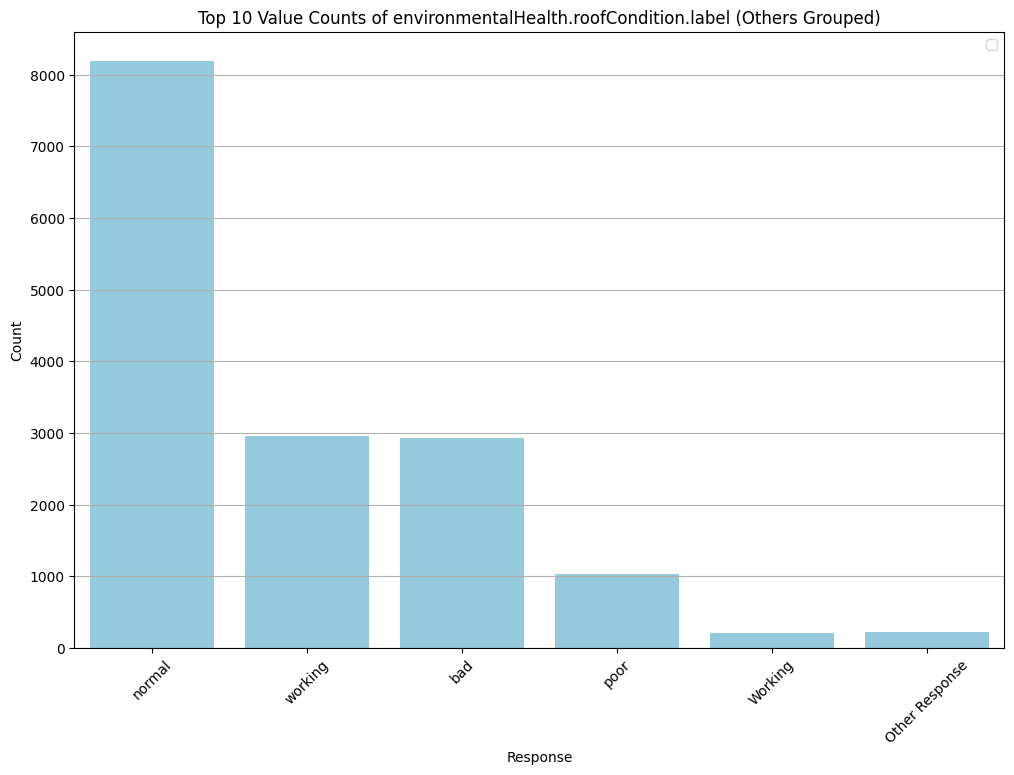

<Figure size 1200x800 with 0 Axes>

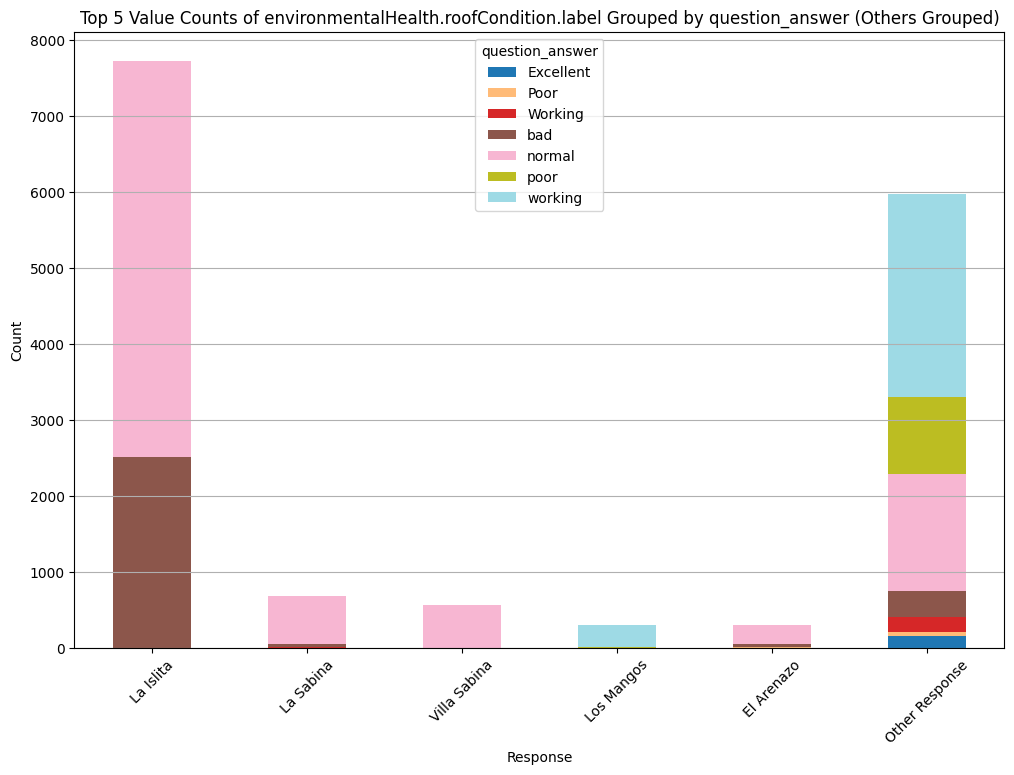

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


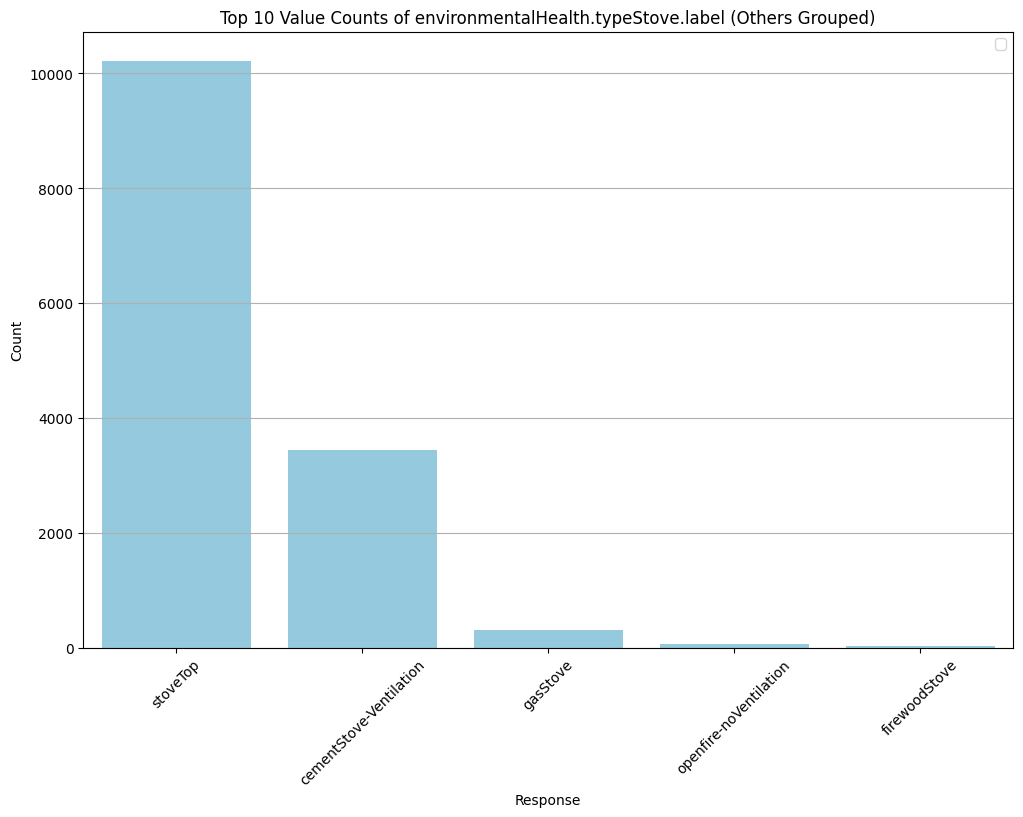

<Figure size 1200x800 with 0 Axes>

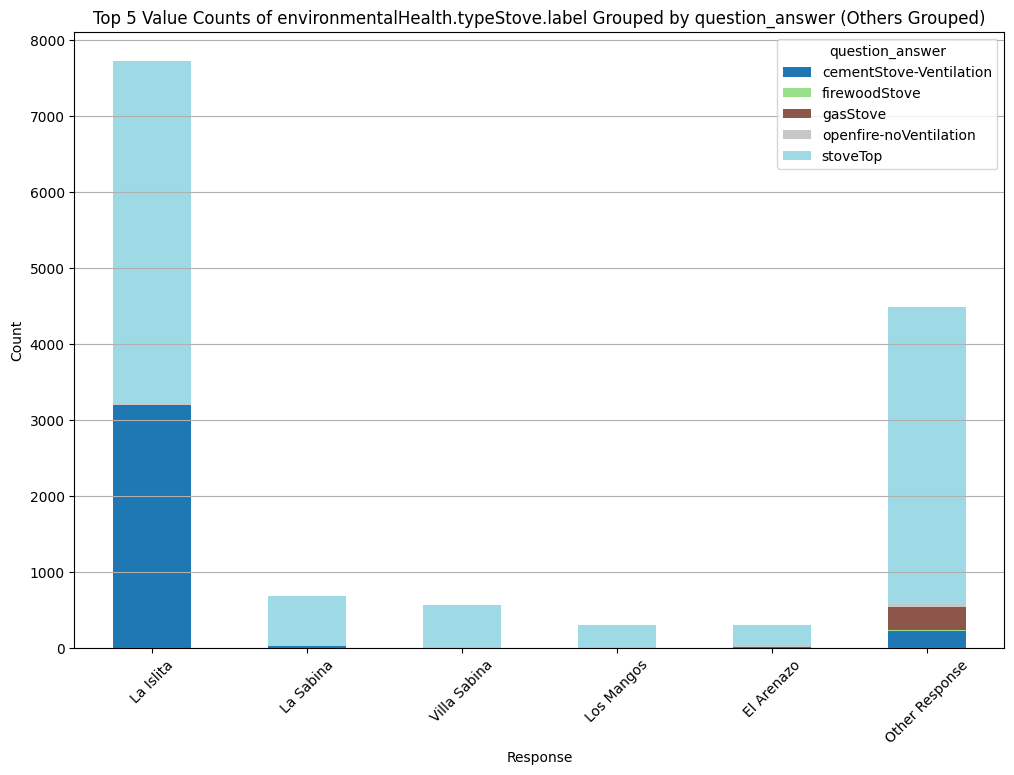

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


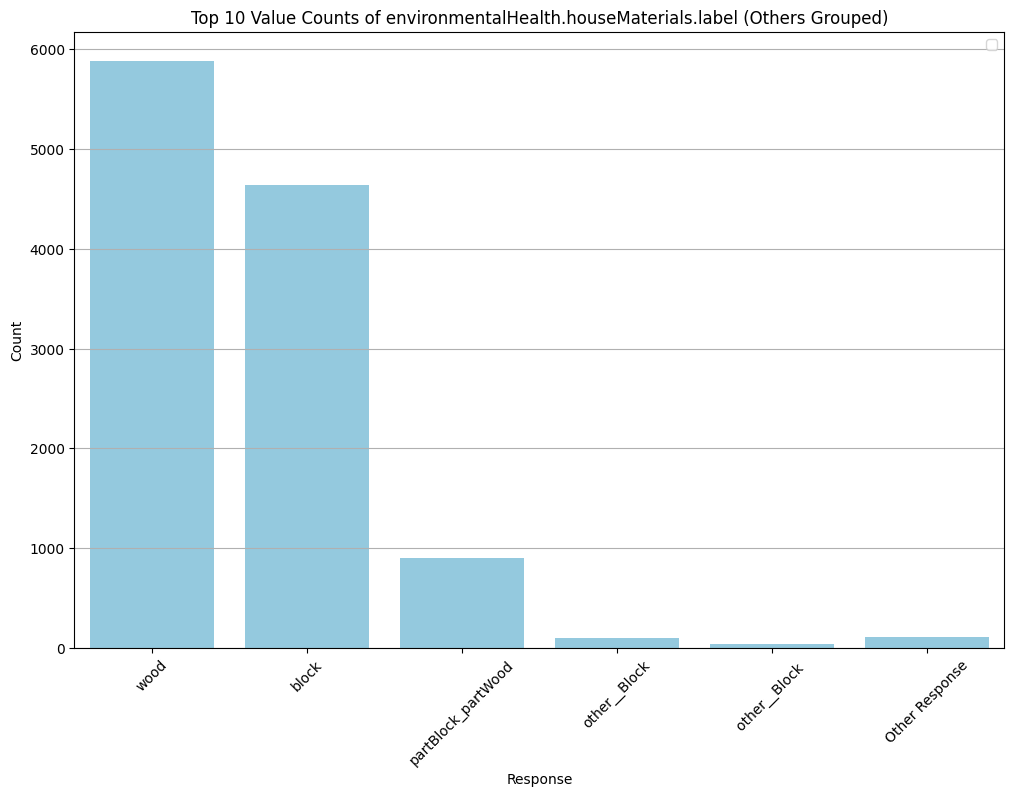

<Figure size 1200x800 with 0 Axes>

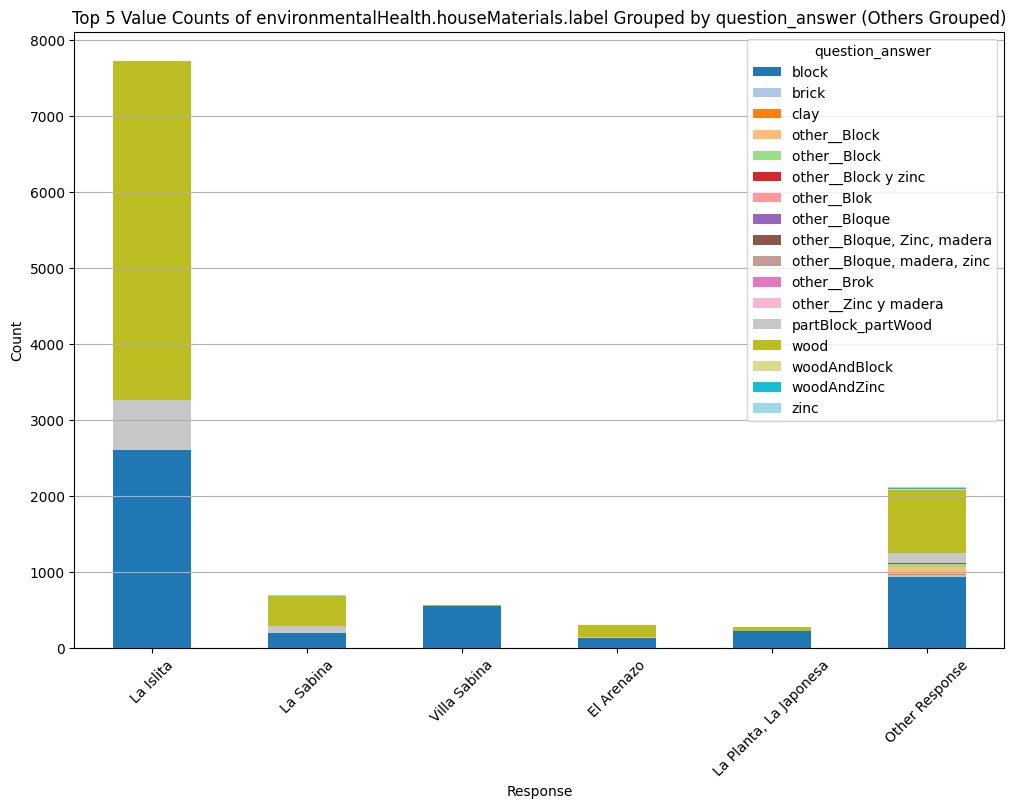

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


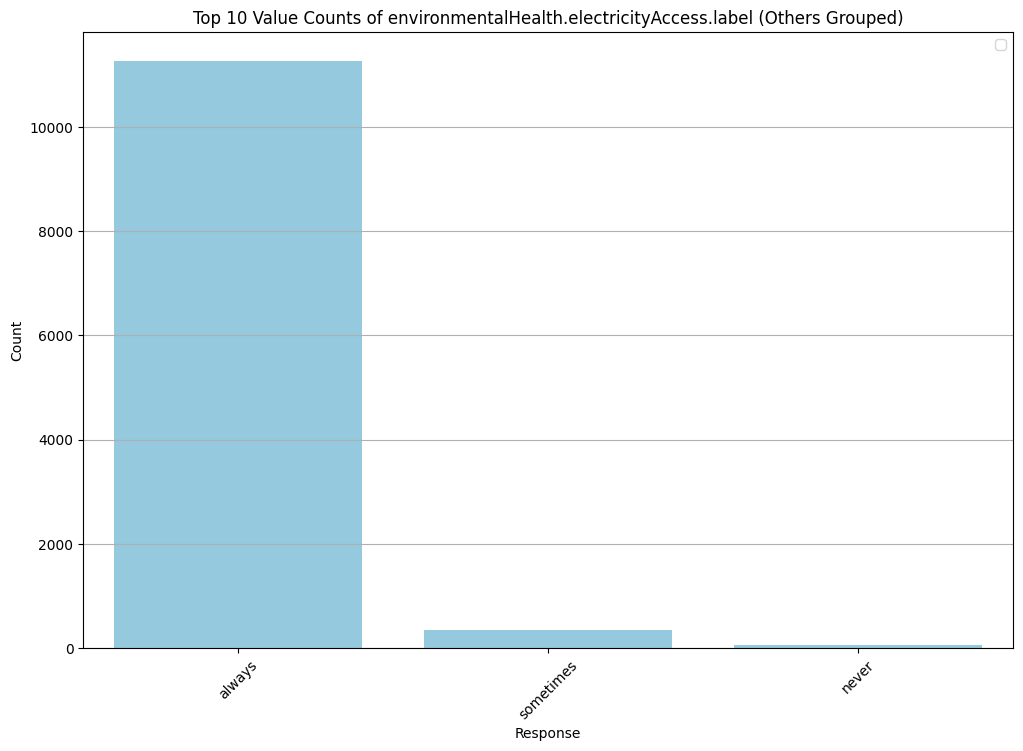

<Figure size 1200x800 with 0 Axes>

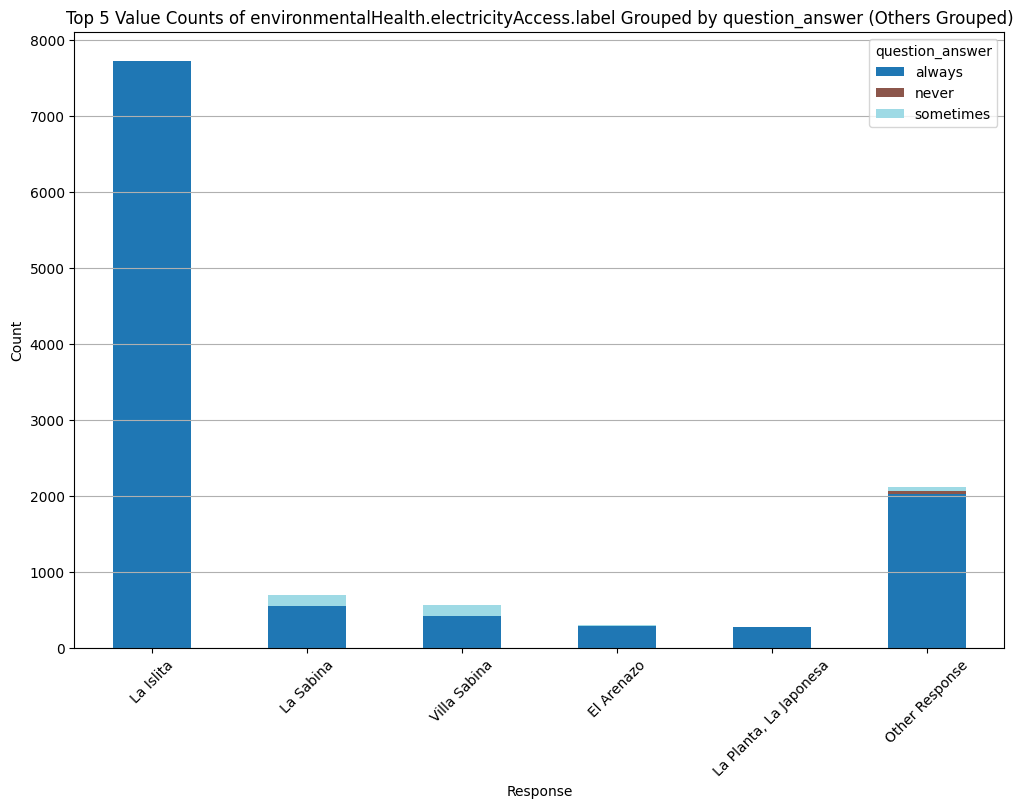

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


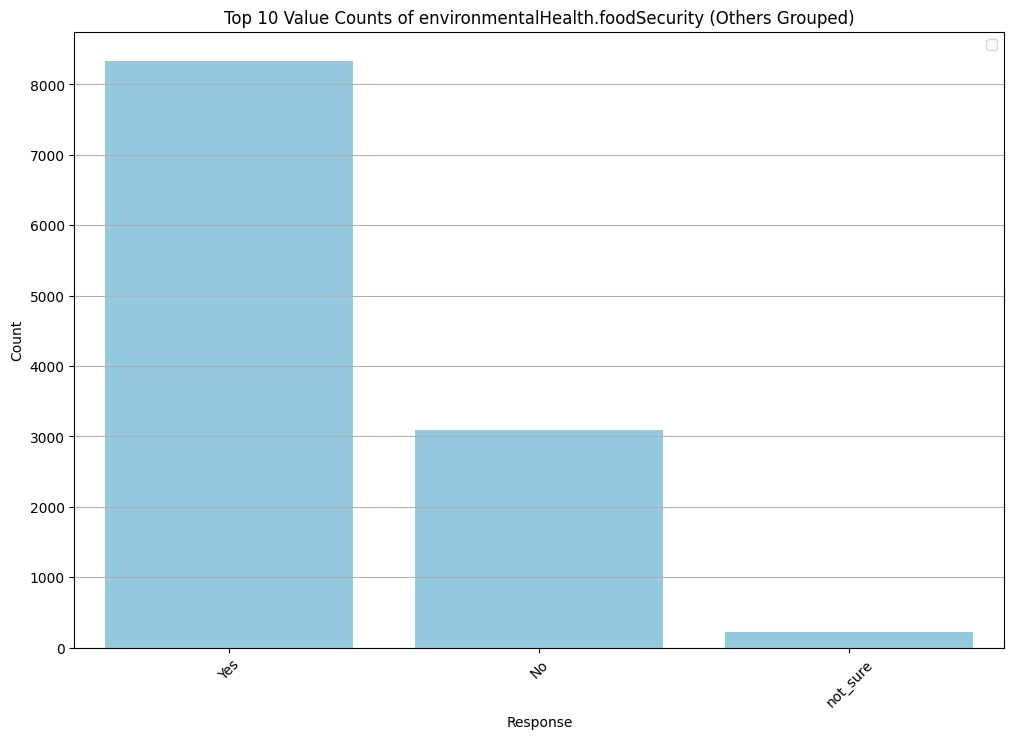

<Figure size 1200x800 with 0 Axes>

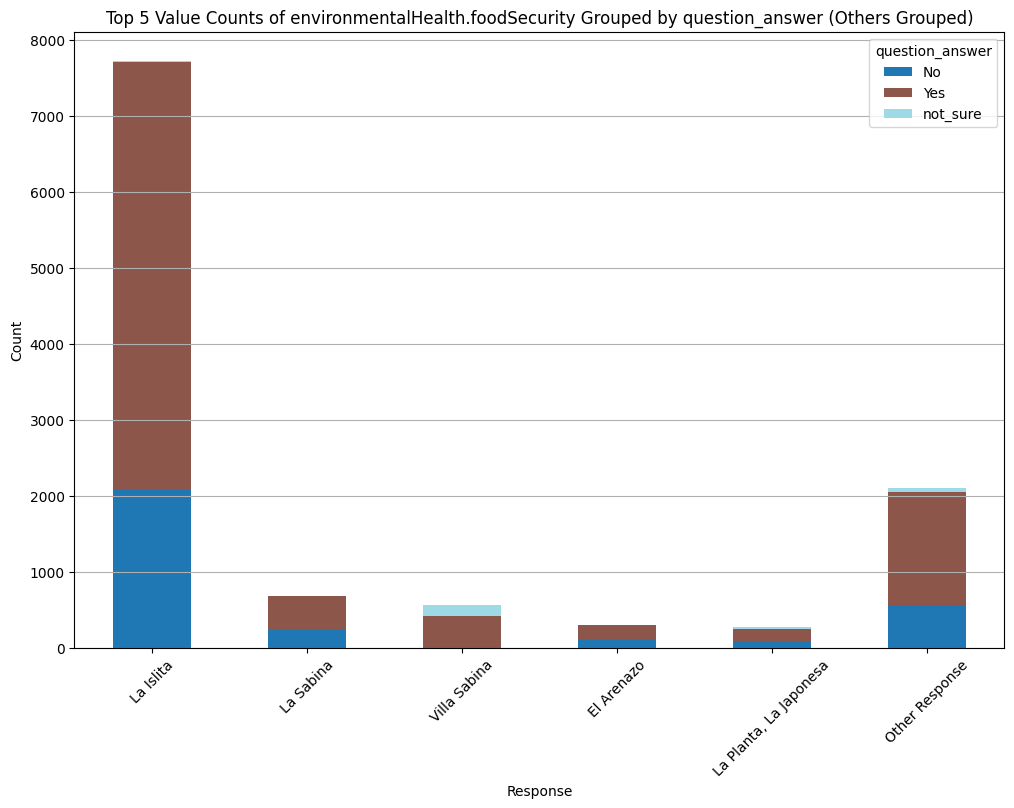

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


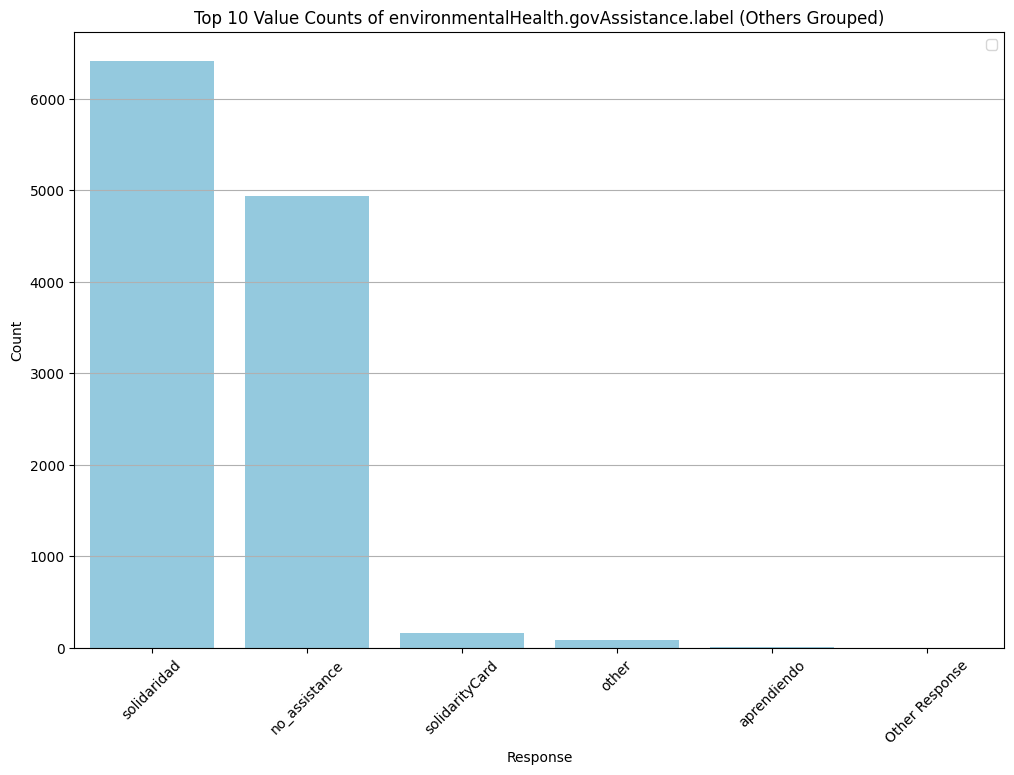

<Figure size 1200x800 with 0 Axes>

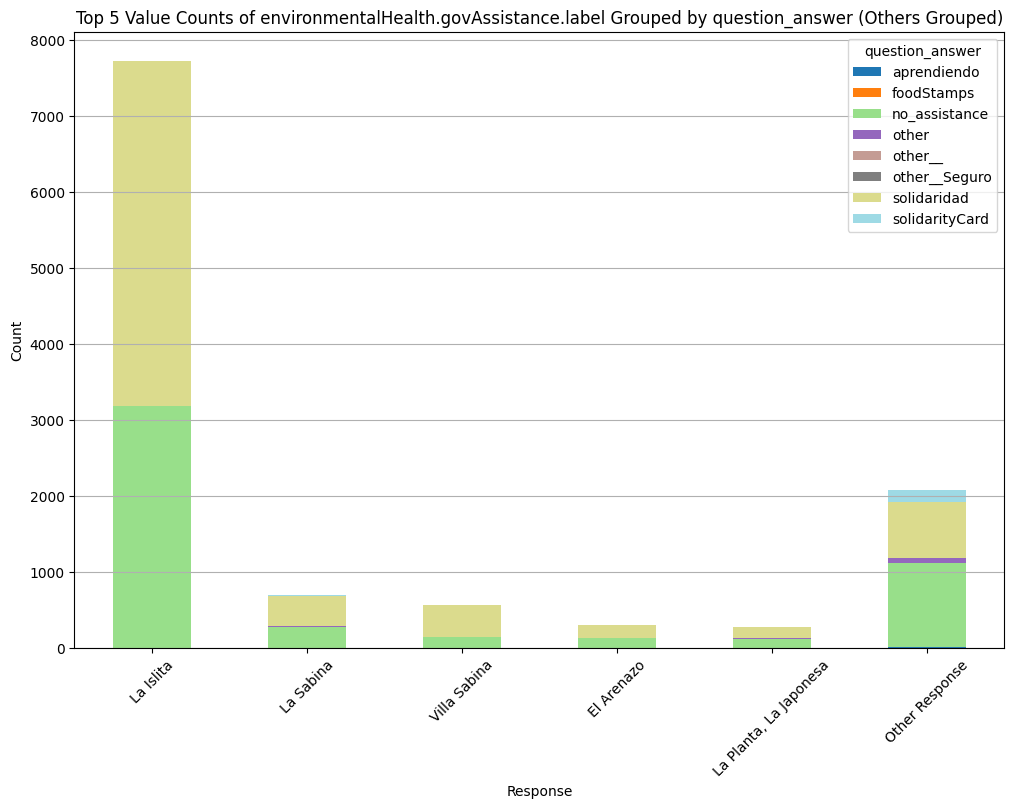

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_5320\3409400035.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=grouping_column)


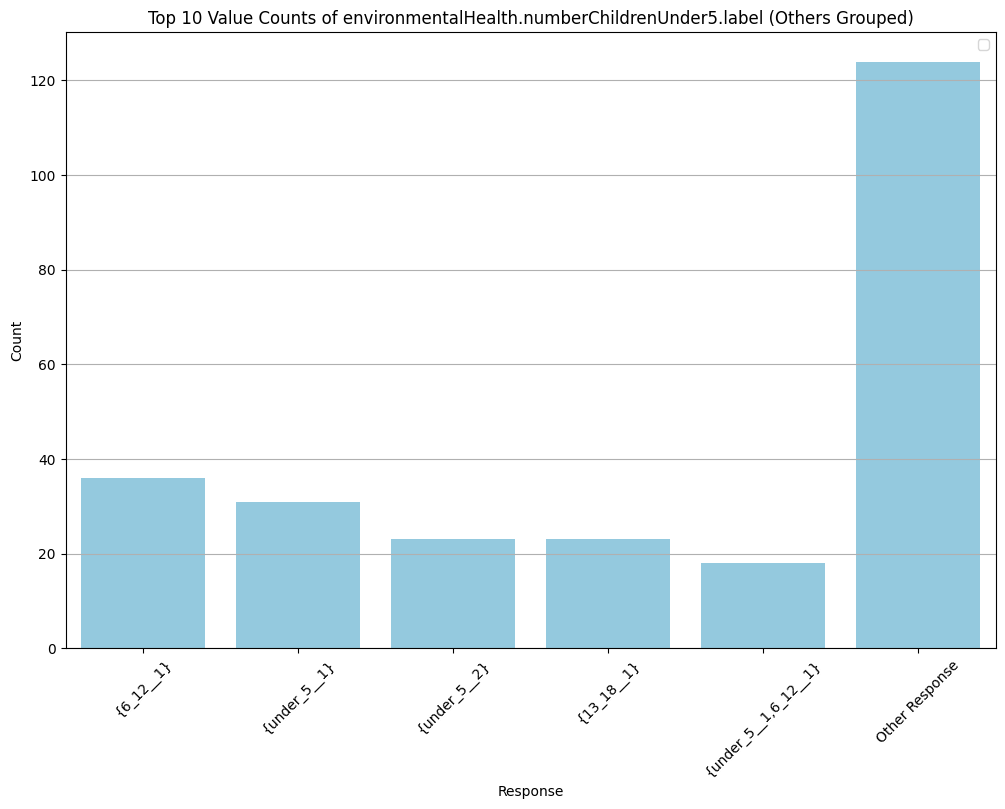

<Figure size 1200x800 with 0 Axes>

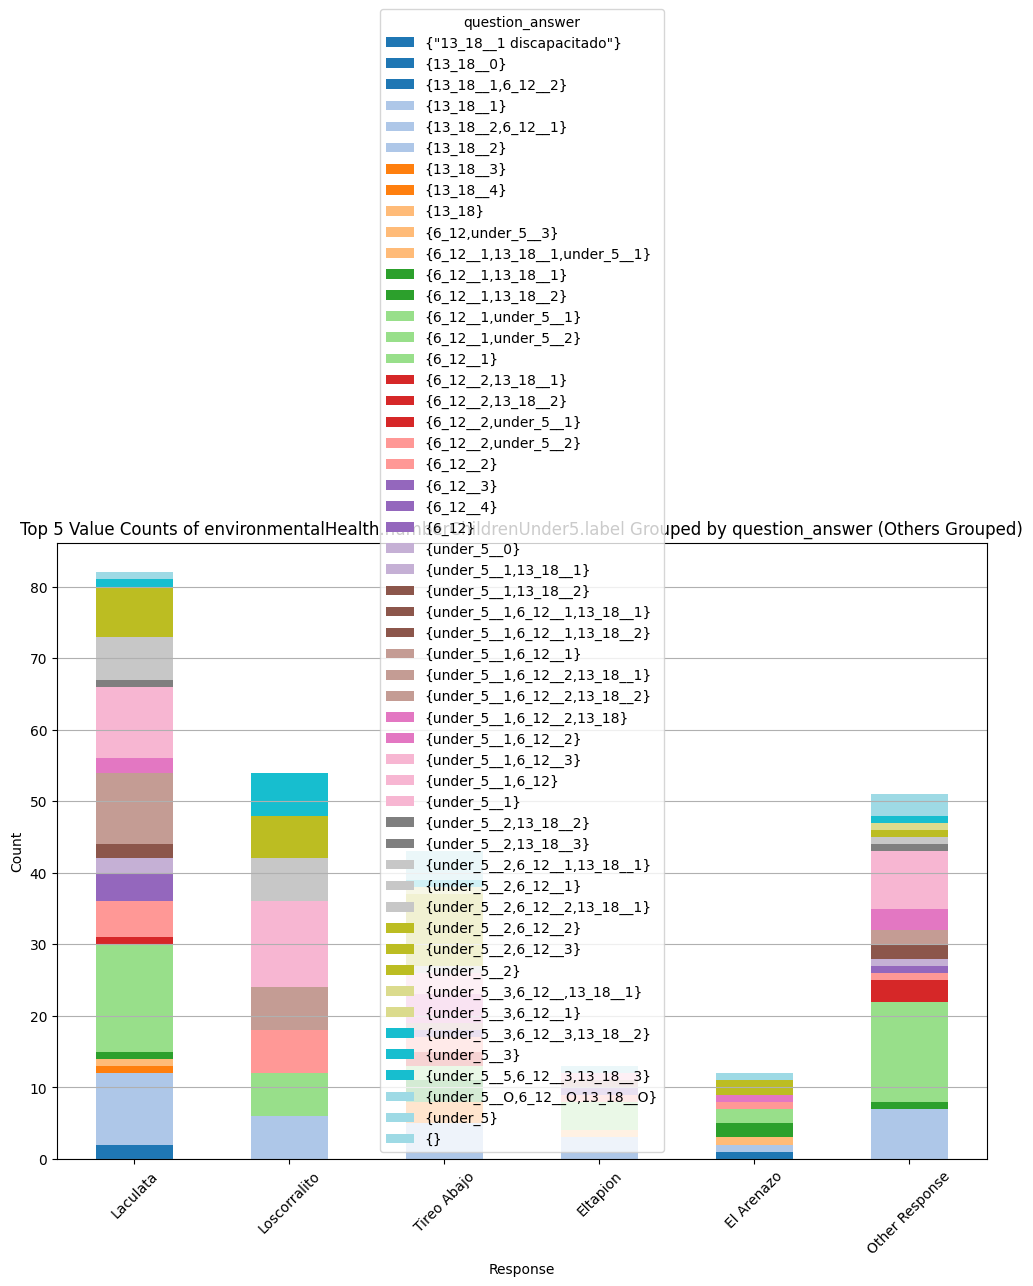

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_responses(df, question, response_column="question_answer", grouping_column=None, stacked=True, top_n=10):
    # Count the occurrences of each value in the specified column grouped by the optional grouping columns
    if grouping_column:
        answer_counts = df.groupby([response_column, grouping_column]).size().unstack(fill_value=0)
    else:
        answer_counts = df[response_column].value_counts().to_frame()
    if answer_counts.shape[0] > top_n:
        # Get the top n values
        top_n_responses = answer_counts.sum(axis=1).nlargest(top_n).index

        # Group all other values as "Other Response"
        plot_df = answer_counts.loc[top_n_responses]
        plot_df.loc['Other Response'] = answer_counts.drop(top_n_responses).sum()
        # Reset index for plotting
        # Prepare the data for plotting
        plot_df = plot_df.reset_index()

        # Plot the stacked bar chart
        plot_df.set_index(response_column, inplace=True)
        
    else:
        plot_df = answer_counts.copy()  

    # Plot the stacked bar chart using seaborn
    plt.figure(figsize=(12, 8))
    if grouping_column:
        plot_df.plot(kind='bar', stacked=stacked, figsize=(12, 8), colormap='tab20')
        plt.title(f'Top {top_n} Value Counts of {question} Grouped by {grouping_column} (Others Grouped)')
        #sns.barplot(x="question_answer", y='count', hue=grouping_column, data=plot_df, palette='tab20', estimator=sum)
    else:
        sns.barplot(x="question_answer", y='count', data=plot_df, color="skyblue", estimator=sum)
        plt.title(f'Top 10 Value Counts of {question} (Others Grouped)')
    plt.xlabel("Response")
    plt.ylabel('Count')
    plt.legend(title=grouping_column)
    plt.xticks(rotation=45)
    plt.grid(axis='y')

    # Show the plot
    plt.show()


top_n = 5
for question in questions:
    question_df = env_health[env_health["question"]==question]
    # plot all responses
    plot_top_responses(question_df, question, top_n = top_n)
    # plot all responses, grouped by survey org
    plot_top_responses(question_df, question, response_column = "community_name", grouping_column="question_answer", stacked=True, top_n=top_n)